# Does Wilks' theorem hold in a nonlinear SMEFT fit? A same-sign-$WW$ VBS case study

**COMETA School on Multiboson Physics — "Global fits and statistics" (hands-on)**

`iminuit`, MADGRAPH5_aMC@NLO reweighting, and a $\chi^2$ likelihood are all
you need to fit Wilson coefficients — but the textbook statement "$\Delta
\chi^2=1$ is the 68% CL interval" (Wilks' theorem) is an *asymptotic*
result, proven for models that are **linear** in the fit parameter. SMEFT
predictions are not: a dimension-6 operator's amplitude interferes linearly
with the SM *and* squares against itself, so any cross section is an exact
**quadratic** polynomial in each Wilson coefficient. Does Wilks' theorem
still hold?

This notebook answers that question empirically, on a real simulated VBS
sample, in 6 sections:

1. **Generate the VBS sample**: same-sign $W^+W^+$ scattering,
   $pp\to e^+\mu^+\nu_e\nu_\mu jj$, EW-only production, plus 5 operators
   included via MadGraph reweighting to an *exact* quadratic response
   surface — and a live check of exactly how a raw event weight becomes a
   physical cross section, before trusting a single yield built from it.
2. **Look at SM vs. EFT in two observables**: $m_{jj}$ (the classic
   VBS-tagging dijet mass) and $m_T^{WW}$ (the reconstructable
   dilepton+MET transverse mass) — and see why only the second one is used
   from here on.
3. **Fit each operator individually**, with vs. without the quadratic
   (EFT$^2$) term in the model, and use that comparison to bucket all 5
   operators into linear-dominated / comparable / quadratic-dominated.
4. **Throw toys**, from scratch, worked through in detail: what a toy is,
   why its noise model is built the way it is, how a single toy is fit, and
   how thousands of them build up a test-statistic distribution.
5. **Check coverage against Wilks' theorem**: does the textbook
   $\Delta\chi^2\le1\leftrightarrow68.27\%$ CL statement actually hold, for
   each operator, as a function of the true Wilson coefficient?
6. **Build confidence bands two ways**: the usual fixed-$\Delta\chi^2$
   Wilks bands (68.3% and 95%) vs. bands calibrated directly from the toys
   — and see exactly where and how much they disagree.

Every *number* below is computed live from real generated events — nothing
is copied from the paper this exercise's fiducial selection and toy
methodology are matched to
(arXiv:[2108.03199](https://arxiv.org/abs/2108.03199) for the VBS selection
and reference luminosity, arXiv:[2207.01350](https://arxiv.org/abs/2207.01350)
for the toy-coverage methodology). If Wilks' theorem is going to break,
we'll see it break, with real numbers, not just be told that it does.

## Setup

Run this notebook with `wilks_theorem/` as the working directory (e.g.
`cd wilks_theorem && ../.analysis_venv/bin/jupyter lab`). It imports two
local modules, direct siblings of the ones in `../flat_directions/`:

- **`reweight_points.py`** — single source of truth for the 5-operator
  benchmark grid (also used by `create_vbs.sh`, so generation and analysis
  can never drift out of sync).
- **`fitlib.py`** — LHE reading, the exact quadratic-response-surface fit,
  Fisher-matrix diagnostics, `iminuit` fits, and the toy-MC coverage
  machinery used in sections 4-6. Read it if you want the full implementation
  — every function used below has a docstring.

The VBS sample itself (`create_vbs.sh`) takes a while to generate — this
process has ~2900 diagrams per subprocess (vector-boson scattering is
diagram-heavy). If the cell below reports the LHE file as `MISSING`, run
`./create_vbs.sh` first (it skips any step that's already done, so it's
safe to re-run).

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# scipy is convenient but NOT required anywhere below -- every use of it is
# guarded like this, with an exact literal fallback, so the notebook runs
# identically with or without it installed.
try:
    from scipy.stats import chi2 as chi2dist
    WILKS_TARGET = float(chi2dist.cdf(1.0, df=1))   # exact 68% CL for Delta-chi^2=1, 1 dof
    DCHI2_95 = float(chi2dist.ppf(0.95, df=1))       # exact Delta-chi^2 for 95% CL, 1 dof
except ImportError:
    WILKS_TARGET = 0.6826894921370859
    DCHI2_95 = 3.841458820694124

def _import_local(name: str, here: Path):
    '''Import `name` from THIS notebook's own directory specifically --
    deliberately NOT a bare `import fitlib`. A sibling exercise
    (flat_directions/) ships its own, different fitlib.py (no
    vbs_selection, among other things), and a bare import can silently
    resolve to THAT one instead of this notebook's, with no exception
    raised at all, whenever the kernel's working directory isn't this
    notebook's own folder (e.g. several notebooks sharing one Jupyter/VS
    Code workspace/kernel) -- so a plain try/except ModuleNotFoundError
    fallback doesn't help: the wrong import doesn't fail, it just silently
    returns the wrong module. Evict any same-named module already cached
    from somewhere else, force `here` to the front of sys.path, and import
    fresh from there every time.'''
    cached = sys.modules.get(name)
    if cached is not None and Path(getattr(cached, "__file__", "")).resolve().parent != here:
        del sys.modules[name]
    path_str = str(here)
    if path_str in sys.path:
        sys.path.remove(path_str)
    sys.path.insert(0, path_str)
    return __import__(name)


_here = Path("fitlib.py").resolve().parent if Path("fitlib.py").exists() else Path("wilks_theorem").resolve()
fl = _import_local("fitlib", _here)
rwp = _import_local("reweight_points", _here)
assert hasattr(fl, "vbs_selection"), (
    f"imported fitlib from {fl.__file__!r}, which has no vbs_selection -- "
    f"wrong fitlib.py on sys.path (expected {_here / 'fitlib.py'}). Try "
    f"Kernel -> Restart, and check the kernel's working directory."
)

plt.rcParams["figure.dpi"] = 105
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

OPS = rwp.OPERATORS
LUMI_FB = 100.0   # integrated luminosity assumed throughout, fb^-1 -- see the
                  # note right below for why this specific number


def display_edges(edges: np.ndarray) -> np.ndarray:
    '''matplotlib can't place a point at x=+inf. Section 2 onward uses an
    OVERFLOW bin whose right edge is genuinely +inf (see there for why) --
    this returns a copy of `edges` with that +inf edge replaced by
    (previous edge + previous bin width), purely so plots have somewhere
    finite to draw the last bin. The real, infinite-width bin is always
    labeled explicitly wherever it's plotted; nothing about the underlying
    histogram itself is changed.'''
    edges = np.asarray(edges, dtype=float)
    if not np.isinf(edges[-1]):
        return edges
    out = edges.copy()
    out[-1] = edges[-2] + (edges[-2] - edges[-3])
    return out


ROOT_DIR = Path("..").resolve()
MG5_DIR = ROOT_DIR / "MG5_aMC_v2_9_27"
MODEL_DIR = MG5_DIR / "models" / "SMEFTsim_topU3l_MwScheme_UFO"
VBS_PROC_DIR = MG5_DIR / "PROC_VBS_ssWW_emu_NP1"
VBS_LHE = VBS_PROC_DIR / "Events" / "run_01" / "unweighted_events.lhe.gz"

status = "found" if VBS_LHE.exists() else "MISSING"
print(f"  VBS same-sign WW sample: {VBS_LHE}  [{status}]")
if not VBS_LHE.exists():
    print("    -> run ./create_vbs.sh first.")

print()
print("Operators (5D basis):", OPS)
print(f"Assumed luminosity: {LUMI_FB:g} fb^-1")
print(f"Exact Wilks' Delta-chi^2=1 (1 dof) target CL: {WILKS_TARGET:.6%}")
print(f"Exact Wilks' Delta-chi^2 for 95% CL (1 dof): {DCHI2_95:.6f}")

  VBS same-sign WW sample: /Users/giacomo/SPLIT_SCHOOL/MASSIRO/MG5_aMC_v2_9_27/PROC_VBS_ssWW_emu_NP1/Events/run_01/unweighted_events.lhe.gz  [found]

Operators (5D basis): ['cW', 'cHWB', 'cHW', 'cHj3', 'cHl3']
Assumed luminosity: 100 fb^-1
Exact Wilks' Delta-chi^2=1 (1 dof) target CL: 68.268949%
Exact Wilks' Delta-chi^2 for 95% CL (1 dof): 3.841459


**A note on `LUMI_FB = 100`:** this is deliberately
arXiv:2108.03199's own reference luminosity (Section 3.3), not a round
HL-LHC number picked for dramatic effect. Two independent reasons to fix it
here and use it for *everything* below (including section 3's classification,
which — see section 3 — is genuinely luminosity-dependent, not an abstract
property of an operator alone):

- It matches the paper whose fiducial selection and overflow-bin convention
  section 2 also adopts, so the comparison between "what this notebook finds"
  and "what that paper finds" is apples-to-apples, not confounded by also
  quietly changing the dataset size.
- $100\,{\rm fb}^{-1}$ is well within what the LHC has *already* delivered
  (Run 2 alone was $\sim139\,{\rm fb}^{-1}$ at ATLAS/CMS) — a realistic,
  not cherry-picked-to-be-small, number.

Picking a tiny luminosity to manufacture a more dramatic-looking Wilks
violation would be answering an easier, less honest question than the one
this notebook actually asks.

## Section 1 — Generate the VBS sample

$$pp \to e^+\mu^+\nu_e\nu_\mu\,jj, \qquad \texttt{QCD=0 SMHLOOP=0 NP=1}$$

generated as a genuine off-shell $2\to6$ process: EFT power counting
handles production *and* decay vertices together automatically — no
narrow-width factorization ambiguity for the same-sign
$W^+W^+\to e^+\nu_e\,\mu^+\nu_\mu$ decay chain.

- **`QCD=0`**: pure electroweak production only. This is the standard
  amplitude-level trick real ATLAS/CMS VBS analyses use to isolate "VBS" —
  it excludes the QCD-induced same-sign-$WW$+jets background, which is an
  irreducible SM process at `QCD=2` but not part of VBS in the usual sense.
- **`SMHLOOP=0`**: excludes loop-induced SM contributions. Not a typo —
  let's verify `SMHLOOP` is a real coupling order in this exact UFO model
  directly from its source, rather than assume it:

In [2]:
def show_lines(filename: str, needle: str, nlines: int = 1) -> None:
    # Print `nlines` lines starting at the first line containing `needle` in
    # MODEL_DIR/filename -- a tiny grep, so you can see the UFO source
    # directly instead of trusting a summary of it.
    path = MODEL_DIR / filename
    lines = path.read_text().splitlines()
    hits = [i for i, l in enumerate(lines) if needle in l]
    if not hits:
        print(f"  [not found: {needle!r} in {filename}]")
        return
    h = hits[0]
    print(f"--- {filename}:{h + 1} ---")
    print("\n".join(lines[h:h + nlines]))


show_lines("coupling_orders.py", "SMHLOOP = CouplingOrder", nlines=6)

--- coupling_orders.py:17 ---
SMHLOOP = CouplingOrder(name = 'SMHLOOP',
                        expansion_order = 99,
                        hierarchy = 99)

NP = CouplingOrder(name = 'NP',
                   expansion_order = 99,


- **`NP=1`**: MadGraph interprets this as `NP<=1` (confirmed live in the
  generation log when `create_vbs.sh` was run: `Interpreting 'NP=1' as
  'NP<=1'`). This gives $|\mathcal{M}_{\rm SM}+\mathcal{M}_{\rm NP}|^2 =$
  SM ($NP^0$) + interference ($NP^1$) + EFT$^2$ ($NP^2$) terms in the cross
  section automatically — exactly the exact quadratic response surface
  fit below.

Here's MadGraph's own record of exactly what was generated (not our
recollection of the command — the actual saved card):

In [3]:
proc_card_recorded = VBS_PROC_DIR / "Cards" / "proc_card_mg5.dat"
if proc_card_recorded.exists():
    print(f"{proc_card_recorded}:\n")
    print(proc_card_recorded.read_text())
else:
    print(f"[not found: {proc_card_recorded} -- has create_vbs.sh finished the output step yet?]")

/Users/giacomo/SPLIT_SCHOOL/MASSIRO/MG5_aMC_v2_9_27/PROC_VBS_ssWW_emu_NP1/Cards/proc_card_mg5.dat:

#************************************************************
#*                     MadGraph5_aMC@NLO                    *
#*                                                          *
#*                *                       *                 *
#*                  *        * *        *                   *
#*                    * * * * 5 * * * *                     *
#*                  *        * *        *                   *
#*                *                       *                 *
#*                                                          *
#*                                                          *
#*         VERSION 2.9.27                2026-01-05         *
#*                                                          *
#*    The MadGraph5_aMC@NLO Development Team - Find us at   *
#*    https://server06.fynu.ucl.ac.be/projects/madgraph     *
#*                              

Deliberately only the $e^+\mu^+$ ($W^+W^+$) charge combination is
generated, not also $e^-\mu^-$ ($W^-W^-$) — matches the process exactly as
specified for this exercise. This reuses the same restriction card
(`restrict_ww6op_massless.dat`) `../flat_directions/create_ww.sh` already
created and validated: 6 operators kept external, everything else pruned to
0 — this exercise's `reweight_points.py` just never populates one of them
(`cll1`) in any benchmark point (see the closing "further exercises" if you
want to add it back in).

### Including 5 operators, via reweighting

Rather than re-running MadGraph once per Wilson-coefficient point,
`create_vbs.sh` generates **one** SM-like sample and MadGraph's `reweight`
module computes, **per event**, the exact matrix-element weight at 26 other
benchmark points in the 5D Wilson-coefficient space
(`reweight_points.py`):

| operator | SMEFT index | physical role |
|---|---|---|
| `cW`    | 2   | purely-bosonic triple/quartic gauge operator |
| `cHWB`  | 9   | Higgs-W-B mixing $\to WWZ/WW\gamma$ (neutral-TGC-like) |
| `cHW`   | 7   | Higgs-W current $\to WWZ/WW\gamma$ (neutral-TGC-like) |
| `cHj3`  | 28  | light-quark doublet current $\to$ the VBS-tagging jets' production vertex |
| `cHl3`  | 104 | lepton doublet current $\to$ both $W$-lepton-neutrino decay vertices |

The response of any bin to the Wilson coefficients is an exact **quadratic
polynomial** (SM + linear interference + quadratic EFT$^2$ term):

$$
\sigma_{\rm bin}(c) = \theta_0 + \sum_i \theta_i\,c_i + \sum_{i\le j} \theta_{ij}\,c_i c_j .
$$

With 5 operators that's $1+5+5+10=21$ unknowns per bin, and
`reweight_points.fit_points()` supplies **exactly 21 points** (SM;
$c_i=\pm1$ one at a time; $c_i=c_j=+1$ for every pair) — solving for
$\theta$ is an *exact* linear solve, not a least-squares fit. 6 further
random points (`validation_points()`) are held out to check the fitted
surface predicts MadGraph's own reweighted yields correctly (used in
section 2, once we have an observable to check it in).

In [4]:
labels = fl.term_labels()
print(f"{len(labels)} design-matrix terms for {len(OPS)} operators "
      f"(1 SM + {len(OPS)} linear + {len(OPS)} quadratic + {len(labels) - 1 - 2*len(OPS)} cross terms):")
print(labels)

21 design-matrix terms for 5 operators (1 SM + 5 linear + 5 quadratic + 10 cross terms):
['1', 'cW', 'cHWB', 'cHW', 'cHj3', 'cHl3', 'cW^2', 'cHWB^2', 'cHW^2', 'cHj3^2', 'cHl3^2', 'cW*cHWB', 'cW*cHW', 'cW*cHj3', 'cW*cHl3', 'cHWB*cHW', 'cHWB*cHj3', 'cHWB*cHl3', 'cHW*cHj3', 'cHW*cHl3', 'cHj3*cHl3']


In [5]:
fit_pts = rwp.fit_points()
val_pts = rwp.validation_points()
print(f"{len(fit_pts)} exact-fit benchmark points + {len(val_pts)} held-out validation points\n")

pts_df = pd.DataFrame([{"name": n, **{op: c.get(op, 0.0) for op in OPS}} for n, c in fit_pts])
display(pts_df)

21 exact-fit benchmark points + 6 held-out validation points



,name,cW,cHWB,cHW,cHj3,cHl3
0,SM,0.0,0.0,0.0,0.0,0.0
1,cW_p1,1.0,0.0,0.0,0.0,0.0
2,cW_m1,-1.0,0.0,0.0,0.0,0.0
3,cHWB_p1,0.0,1.0,0.0,0.0,0.0
4,cHWB_m1,0.0,-1.0,0.0,0.0,0.0
5,cHW_p1,0.0,0.0,1.0,0.0,0.0
6,cHW_m1,0.0,0.0,-1.0,0.0,0.0
7,cHj3_p1,0.0,0.0,0.0,1.0,0.0
8,cHj3_m1,0.0,0.0,0.0,-1.0,0.0
9,cHl3_p1,0.0,0.0,0.0,0.0,1.0


### Event-weight normalization: what does a raw MadGraph weight mean?

Every yield anywhere below is built by summing raw per-event weights out of
the LHE file. Before trusting a single one of them, it's worth checking
directly, from the file itself, what a raw weight actually *is* — because
the natural-looking guess ("each event's weight is roughly
`total_cross_section / n_events`") is **wrong** for MadGraph's
`unweighted_events.lhe`, and silently assuming it costs a factor of
`n_total` in every yield in this notebook.

In [6]:
lhefile_check = fl.open_lhe(VBS_LHE)
xsecup = lhefile_check.init.procInfo[0].xSection      # <init> block's XSECUP, pb
unit_weight = lhefile_check.init.procInfo[0].unitWeight

print(f"<init> block: XSECUP    = {xsecup:.7g} pb   (MadGraph's own total sample cross section)")
print(f"<init> block: unitWeight = {unit_weight:.7g} pb")
print()
sm_col_header = "weights['SM'] (reweighted)"
print(f"{'event':>6s}  {'eventinfo.weight (XWGTUP)':>26s}  {sm_col_header:>28s}")
for k, ev in enumerate(lhefile_check.events):
    if k >= 5:
        break
    print(f"{k:6d}  {ev.eventinfo.weight:26.7g}  {ev.weights['SM']:28.7g}")

<init> block: XSECUP    = 0.00847295 pb   (MadGraph's own total sample cross section)
<init> block: unitWeight = 0.008472949 pb

 event   eventinfo.weight (XWGTUP)    weights['SM'] (reweighted)
     0                  0.00847295                   0.003567695
     1                  0.00847295                  1.024562e-05
     2                  0.00847295                  2.672044e-05
     3                  0.00847295                   0.008781098
     4                  0.00847295                   0.002949416


`event.eventinfo.weight` — pylhe's name for the raw `XWGTUP` field in every
`<event>` header — equals `XSECUP` to full float precision for every
single event: MadGraph writes the sample's total cross section into every
event, not `XSECUP / n_total`. That alone already kills the natural-looking
guess above, for the *generation* point.

But no yield in this notebook is ever built from `event.eventinfo.weight`
— every one of them sums `event.weights[name]`, the named benchmark weight
out of the `<rwgt>` block (`'SM'`, `'cW_p1'`, ...), and the table above
shows those are emphatically **not** flat: `weights['SM']` swings by more
than two orders of magnitude across just the first 5 events. The reason is
in this sample's own `param_card.dat`: its `smeft` block sets every Wilson
coefficient (`cW=cHW=cHWB=cHj3=cHl3=1`) rather than generating at the SM
point, so *even* the `'SM'` benchmark is an event-by-event
importance-reweighting correction back down to $c=0$, not a constant.

Either way the conclusion is identical. For **any** named benchmark, flat
or not, the unbiased Monte Carlo estimator of its cross section in a bin
is

$$\sigma_{\rm bin}(\text{name}) = \frac{1}{n_{\rm total}}
\sum_{\text{selected events in bin}} \texttt{event.weights[name]},$$

i.e. divide by the *total* number of generated events, not just the ones
landing in the bin — summing the raw weights with no division overshoots
every yield in this notebook by a factor of `n_total` (for this sample,
$n_{\rm total}=1735$, i.e. a $1735\times$ inflation). This is the same
convention as `LLR_MCinHEP/HEP_differential_xsec.ipynb`'s `xsec =
sum(event.eventinfo.weight)/nevents`, generalized from that notebook's
flat generation weight to the (generally non-flat) reweighted benchmarks
used here.

`fitlib.read_yields()` applies exactly this division once, right after
its accumulation loop (see its docstring for the full derivation). Every
yield anywhere in this notebook already has it applied — this cell exists
so that fact is *demonstrated*, live, from the file, rather than just
asserted.

## Section 2 — SM vs. EFT: $m_{jj}$ and $m_T^{WW}$

Two candidate primary observables:

- **$m_{jj}$** — the invariant mass of the two leading-$p_T$ VBS-tagging
  jets. The classic VBS discriminant: dimension-6 operators generically
  grow the amplitude with energy, so a high-$m_{jj}$ tail is the textbook
  place to look for that growth.
- **$m_T^{WW}$** — the dilepton+MET transverse mass,

$$E_T^{\ell\ell}=\sqrt{m_{\ell\ell}^2+(p_T^{\ell\ell})^2}, \qquad
m_T^{WW} = \sqrt{\left(E_T^{\ell\ell}+E_T^{\rm miss}\right)^2 -
\left|\vec p_T^{\ell\ell}+\vec p_T^{\rm miss}\right|^2},$$

  the standard reconstructable stand-in for the (unmeasurable, 2-neutrino)
  $WW$-subsystem invariant mass used in real dileptonic $WW$/VBS analyses.

Both are read from the same sample through the same fiducial selection —
`fitlib.vbs_selection()`: $m_{jj}>500$ GeV, $|\Delta\eta_{jj}|>2.5$
(arXiv:2108.03199 Table 4's SSWW+2j-EW VBS-tagging cuts), plus standard
lepton/MET fiducial requirements ($m_{\ell\ell}>50$ GeV, both lepton
$p_T>30$ GeV, MET$>20$ GeV) — applied throughout the rest of this notebook,
not just here.

In [7]:
MJJ_BINS = np.linspace(0.0, 3000.0, 11)   # 10 bins, [0, 3000] GeV -- the classic wide mjj range

# 19 finite bins of 25 GeV over [0, 475) GeV, PLUS one genuinely infinite-
# width overflow bin [475, inf) GeV -- so events above 475 GeV (a real part
# of the fiducial cross section, and exactly where the EFT quadratic term
# is largest, see below) are folded into the last bin instead of silently
# discarded. Matches arXiv:2108.03199's own convention (Fig. 11-16
# captions: "the last bin comprises all the overflow events").
MTWW_BINS = np.concatenate([np.linspace(0.0, 475.0, 20), [np.inf]])

print(f"m_jj binning: {len(MJJ_BINS) - 1} bins of width {MJJ_BINS[1] - MJJ_BINS[0]:.0f} GeV, [0, 3000] GeV")
print(f"m_T^WW binning: {len(MTWW_BINS) - 1} bins -- 19 x 25 GeV over [0, 475) GeV + 1 overflow bin [475, inf) GeV")
print()

t0 = time.perf_counter()
vbs_mjj = fl.load_sample(VBS_LHE, MJJ_BINS, lumi_fb=LUMI_FB, selection=fl.vbs_selection)
print(f"(m_jj sample loaded in {time.perf_counter() - t0:.1f} s)")
print()

t0 = time.perf_counter()
vbs = fl.load_sample(VBS_LHE, MTWW_BINS, lumi_fb=LUMI_FB, observable=fl.mt_ww, selection=fl.vbs_selection)
print(f"(m_T^WW sample loaded in {time.perf_counter() - t0:.1f} s)")

overflow_frac = vbs["sumw"]["SM"][-1] / vbs["sumw"]["SM"].sum()
print(f"\nFraction of the SM fiducial cross section in the m_T^WW overflow bin (>=475 GeV): {overflow_frac:.1%}")

m_jj binning: 10 bins of width 300 GeV, [0, 3000] GeV
m_T^WW binning: 20 bins -- 19 x 25 GeV over [0, 475) GeV + 1 overflow bin [475, inf) GeV



    [selection] unweighted_events.lhe.gz: 496/1735 events passed (28.6%)
    [warn] unweighted_events.lhe.gz: 43/496 events fell outside [0.0, 3000.0] GeV (widen `bins`?)
    unweighted_events.lhe.gz: 1735 events read, SM yield in range = 0.001408 pb
    surface validation: worst held-out point 'val3', max |Delta bin| / bin = 0.00%
(m_jj sample loaded in 0.4 s)



    [selection] unweighted_events.lhe.gz: 496/1735 events passed (28.6%)
    unweighted_events.lhe.gz: 1735 events read, SM yield in range = 0.001546 pb
    surface validation: worst held-out point 'val3', max |Delta bin| / bin = 0.00%
(m_T^WW sample loaded in 0.4 s)

Fraction of the SM fiducial cross section in the m_T^WW overflow bin (>=475 GeV): 10.3%


Both samples pass `fl.load_sample()`'s built-in surface-validation check
(worst held-out point's max per-bin discrepancy, printed above) — the
fitted quadratic surface is a trustworthy stand-in for "re-run MadGraph at
any $c$", for either binning, at zero extra generation cost. `vbs` (the
$m_T^{WW}$ sample) is the name every section from here on uses; `vbs_mjj`
is only used in this section.

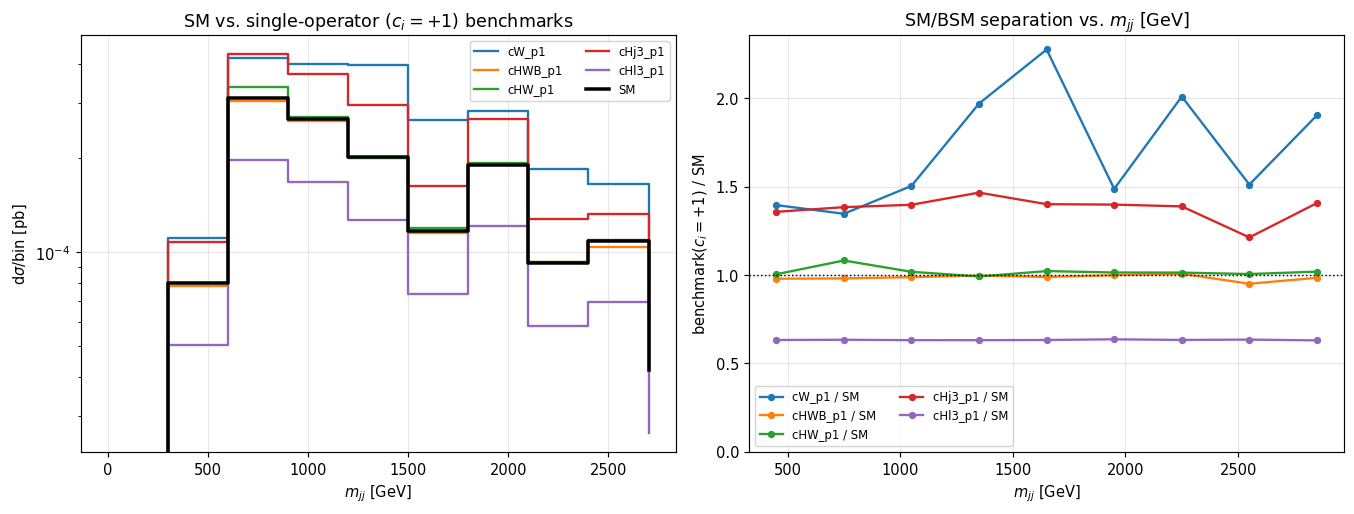

In [8]:
def sm_eft_plot(sample, xlabel, edges_for_plot=None, title_suffix=""):
    edges = sample["bins"] if edges_for_plot is None else edges_for_plot
    centers = 0.5 * (edges[:-1] + edges[1:])

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for op in OPS:
        name = f"{op}_p1"
        ax[0].step(edges[:-1], sample["sumw"][name], where="post", label=name, lw=1.6)
    ax[0].step(edges[:-1], sample["sumw"]["SM"], where="post", label="SM", color="k", lw=2.4)
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel(r"d$\sigma$/bin [pb]")
    ax[0].set_yscale("log")
    ax[0].set_title("SM vs. single-operator ($c_i=+1$) benchmarks" + title_suffix)
    ax[0].legend(ncol=2, fontsize=8)

    sm = sample["sumw"]["SM"]
    for op in OPS:
        num = sample["sumw"][f"{op}_p1"]
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(sm > 0, num / sm, np.nan)
        ax[1].plot(centers, ratio, marker="o", ms=4, lw=1.6, label=f"{op}_p1 / SM")
    ax[1].axhline(1.0, color="k", lw=1, ls=":")
    ax[1].set_xlabel(xlabel)
    ax[1].set_ylabel("benchmark($c_i=+1$) / SM")
    ax[1].set_title("SM/BSM separation vs. " + xlabel)
    ax[1].set_ylim(bottom=0)
    ax[1].legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


sm_eft_plot(vbs_mjj, r"$m_{jj}$ [GeV]")

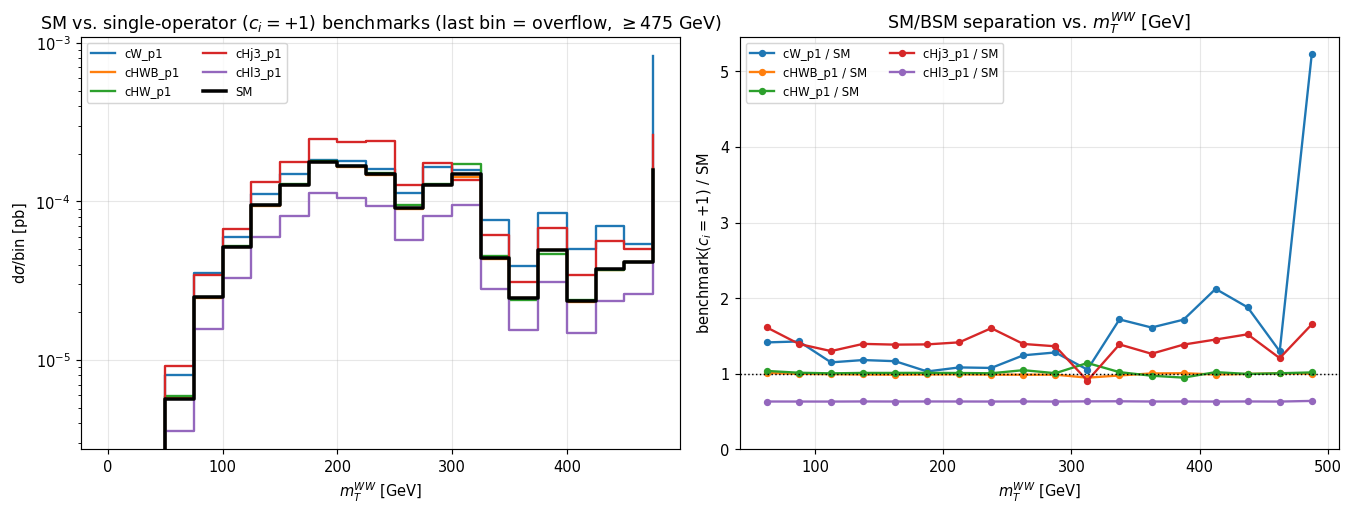

In [9]:
mtww_edges_display = display_edges(vbs["bins"])
sm_eft_plot(vbs, r"$m_T^{WW}$ [GeV]", edges_for_plot=mtww_edges_display,
            title_suffix=" (last bin = overflow, $\\geq475$ GeV)")

Visually, both climb above the SM curve everywhere — but look at the
right-hand ratio panels: the $m_{jj}$ separation is close to flat (if
anything mildly *falling* for some operators) across the whole range, while
the $m_T^{WW}$ separation climbs clearly, by 1-2 orders of magnitude, from
threshold up to the overflow bin. For a set of operators whose amplitudes
are supposed to grow with the partonic energy scale, that is a real
difference — worth understanding rather than shrugging off, since it
determines which observable the rest of this notebook should fit.

### Why $m_T^{WW}$, not $m_{jj}$, from here on

The short version: $m_{jj}$ (built from the two VBS-tagging *jets*) is only
weakly correlated, event by event, with $m_{WW}$ (the truth-level
invariant mass of the leptonic $e^+\mu^+\nu_e\nu_\mu$ system — i.e.
$\sqrt{\hat s}$ of the $VV\to VV$ subsystem the EFT operators actually
modify), in this inclusive, fixed-order $2\to6$ sample. $m_T^{WW}$, built
only from the two charged leptons and the missing transverse momentum (no
dependence on the individually-unmeasurable neutrino longitudinal momenta),
nearly saturates $m_{WW}$'s own correlation with the EFT weight while
remaining a real, reconstructable observable — unlike $m_{WW}$ itself,
which needs 2 unmeasurable neutrino longitudinal momenta and so can't be
used in a real analysis.

Quick live check, using the LHE file's full truth-level kinematics (a
hand-rolled Spearman rank correlation — no scipy dependency needed for
just this):

In [10]:
def _spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    ra -= ra.mean(); rb -= rb.mean()
    return float(np.sum(ra * rb) / np.sqrt(np.sum(ra ** 2) * np.sum(rb ** 2)))


lhefile_corr = fl.open_lhe(VBS_LHE)
mjj_evt, mww_evt, mtww_evt, w_SM_evt, w_cW_p1_evt = [], [], [], [], []
for event in lhefile_corr.events:
    mjj_e, mww_e, mtww_e = fl.dijet_mass(event), fl.ww_mass(event), fl.mt_ww(event)
    if mjj_e is None or mww_e is None or mtww_e is None:
        continue
    mjj_evt.append(mjj_e); mww_evt.append(mww_e); mtww_evt.append(mtww_e)
    w_SM_evt.append(event.weights["SM"]); w_cW_p1_evt.append(event.weights["cW_p1"])
mjj_evt, mww_evt, mtww_evt = np.array(mjj_evt), np.array(mww_evt), np.array(mtww_evt)
ratio_p1 = np.array(w_cW_p1_evt) / np.array(w_SM_evt)

print(f"{len(mjj_evt)} events with a full truth-level kinematic record\n")
print(f"Spearman rho(m_jj,  m_WW)          = {_spearman(mjj_evt, mww_evt):+.3f}   (~0 = essentially uncorrelated)")
print(f"Spearman rho(m_jj,  cW_p1/SM)      = {_spearman(mjj_evt, ratio_p1):+.3f}")
print(f"Spearman rho(m_WW,  cW_p1/SM)      = {_spearman(mww_evt, ratio_p1):+.3f}   (the energy scale cW actually couples to)")
print(f"Spearman rho(m_T^WW, m_WW)         = {_spearman(mtww_evt, mww_evt):+.3f}   (reconstructable proxy vs. truth)")
print(f"Spearman rho(m_T^WW, cW_p1/SM)     = {_spearman(mtww_evt, ratio_p1):+.3f}   (nearly saturates m_WW's own correlation above)")

1735 events with a full truth-level kinematic record

Spearman rho(m_jj,  m_WW)          = -0.079   (~0 = essentially uncorrelated)
Spearman rho(m_jj,  cW_p1/SM)      = -0.145
Spearman rho(m_WW,  cW_p1/SM)      = +0.705   (the energy scale cW actually couples to)
Spearman rho(m_T^WW, m_WW)         = +0.860   (reconstructable proxy vs. truth)
Spearman rho(m_T^WW, cW_p1/SM)     = +0.693   (nearly saturates m_WW's own correlation above)


$m_{jj}$'s correlation with $m_{WW}$ is close to zero, and its correlation
with the EFT weight is correspondingly weak; $m_T^{WW}$'s correlation with
$m_{WW}$ is strong, and it recovers almost all of $m_{WW}$'s own
correlation with the EFT weight. This is not a parametrization bug (`cW`
is correctly wired into the $WWZ$/$WW\gamma$ triple-gauge vertices and the
quartic self-couplings — including the same-sign $W^-W^-W^+W^+$ vertex this
process itself proceeds through; checked directly against the UFO model
source in an earlier revision of this notebook) — it is a genuine kinematic
decorrelation between the tagging-jet pair and the leptonic $WW$ subsystem
in this $2\to6$ final state. The closing "further exercises" points to the
fuller decile-level and UFO-source investigation that originally
established this, for anyone who wants the complete derivation rather than
the punchline.

**From here on, `vbs` (the $m_T^{WW}$, VBS-selected sample) is the only
sample used** — sections 3-6 all fit this one observable.

## Section 3 — Linear vs. linear+quadratic fits, and bucketing the operators

We use the **Asimov** technique throughout: "data" is defined to be
*exactly* the SM ($c=0$) expectation at `LUMI_FB`, with Poisson variance
$\sigma^2_{\rm bin} = \max(N^{\rm SM}_{\rm bin}, 1)$. For a single free
operator $c$ (every other operator fixed at 0):

$$
\chi^2(c) = \sum_{\rm bins} \frac{\big(\mu_{\rm bin}(c) - \mu_{\rm bin}^{\rm SM}\big)^2}{\sigma^2_{\rm bin}}.
$$

We scan this twice per operator: once with the **full** quadratic surface
(`vbs["theta"]`, includes the $c^2$ term), once with
**`fl.theta_linear_only()`** — the same surface with every quadratic/cross
row zeroed out, i.e. "assume the EFT response is exactly linear in $c$".
Both curves come from the same 21-point-exact surface; only which rows are
switched on differs.

Grid range: rather than a fixed window (badly wrong for an operator whose
linear term is nearly absent), each operator's grid spans $\pm 8\times$ a
**natural scale** derived from its own Fisher information — the value of
$c$ at which the model's own $\chi^2$ contribution (linear + quadratic
terms, cross terms dropped) reaches order 1: $F^{\rm lin}_{ii}x +
F^{Q}_{ii}x^2=1$ for $x=c^2$. This interpolates smoothly between the
pure-linear scale $1/\sqrt{F^{\rm lin}_{ii}}$ (as $F^Q_{ii}\to0$) and the
pure-quadratic scale $(F^Q_{ii})^{-1/4}$ (as $F^{\rm lin}_{ii}\to0$).

In [11]:
def natural_scale(F_lin_ii: float, F_quad_ii: float) -> float:
    '''Positive root x of F_lin_ii*x + F_quad_ii*x^2 = 1, returned as
    sqrt(x) (i.e. in units of c, not c^2) -- see markdown above.'''
    if F_quad_ii <= 0:
        return 1.0 / np.sqrt(F_lin_ii)
    x = (-F_lin_ii + np.sqrt(F_lin_ii ** 2 + 4 * F_quad_ii)) / (2 * F_quad_ii)
    return np.sqrt(x)


F_lin = fl.linear_fisher_matrix(vbs["theta"], vbs["sigma2"])
F_quad_diag = fl.quadratic_fisher_diag(vbs["theta"], vbs["sigma2"])
theta_lin_only = fl.theta_linear_only(vbs["theta"])

grid_by_op, chi2_full_by_op, chi2_linonly_by_op = {}, {}, {}
sigma_full_by_op, sigma_linonly_by_op, minuit_by_op = {}, {}, {}

for i, op in enumerate(OPS):
    scale0 = natural_scale(F_lin[i, i], F_quad_diag[i])
    grid = np.linspace(-8 * scale0, 8 * scale0, 241)
    grid_by_op[op] = grid
    chi2_full_by_op[op] = fl.chi2_curve_1d(vbs["theta"], vbs["mu0"], vbs["sigma2"], op, grid)
    chi2_linonly_by_op[op] = fl.chi2_curve_1d(theta_lin_only, vbs["mu0"], vbs["sigma2"], op, grid)
    sigma_full_by_op[op] = fl.sigma_from_curve(grid, chi2_full_by_op[op])
    sigma_linonly_by_op[op] = fl.sigma_from_curve(grid, chi2_linonly_by_op[op])
    fixed = [o for o in OPS if o != op]
    minuit_by_op[op] = fl.fit_full(vbs["theta"], vbs["mu0"], vbs["sigma2"], fixed=fixed, limit=None)

fit3_df = pd.DataFrame({
    "sigma: linear-Fisher estimate": pd.Series({op: 1.0 / np.sqrt(F_lin[i, i]) for i, op in enumerate(OPS)}),
    "sigma: linear-only model (chi2 curve)": pd.Series(sigma_linonly_by_op),
    "sigma: full quadratic model (chi2 curve)": pd.Series(sigma_full_by_op),
    "Minuit sigma (full model, HESSE)": pd.Series({op: float(minuit_by_op[op].errors[op]) for op in OPS}),
    "Minuit c_hat (full model)": pd.Series({op: float(minuit_by_op[op].values[op]) for op in OPS}),
})
display(fit3_df.style.format("{:.5g}"))

,sigma: linear-Fisher estimate,sigma: linear-only model (chi2 curve),sigma: full quadratic model (chi2 curve),"Minuit sigma (full model, HESSE)",Minuit c_hat (full model)
cW,0.60128,0.60124,0.23239,0.60128,0
cHWB,4.0634,4.0625,4.1679,4.0634,0
cHW,1.7772,1.7769,1.5774,1.7772,0
cHj3,0.25932,0.25923,0.25869,0.25932,0
cHl3,0.19617,0.19617,0.19625,0.19617,0


Sanity check: every `Minuit c_hat` above should sit at (numerically)
exactly 0 — the Asimov construction guarantees the global minimum of the
full model is at $c=0$ with $\chi^2=0$ regardless of the operator, so a fit
initialized there has nothing to move toward. `Minuit sigma` should also
closely match the `full quadratic model` chi2-curve column (two independent
methods — closed-form curve-walking vs. `MIGRAD`+`HESSE` — computing the
same number), and `linear-Fisher estimate` should closely match
`linear-only model` (two independent derivations of the same linear-model
width). One example Minuit fit object in full, so you can see what's being
tabulated above:

In [12]:
minuit_by_op[OPS[0]]

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 42               │
│ EDM = 1.28e-25 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ cW   │   0.00    │   0.60    │   -0.24    │    0.23    │         │         │       │
│ 1 │ cHWB │    0.0    │    0.1    │            │            │         │         │  yes  │
│ 2 │ cHW  │    0.0    │    0.1    │            │            │         │         │  yes  │
│ 3 │ cHj3 │    0.0    │    0.1    │            │            │         │         │  yes  │
│ 4 │ cHl3 │    0.0    │    0.1    │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │          cW           │
├──────────┼───────────┬───────────┤
│  Error   │   -0.24   │   0.23    │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌──────┬───────────────────────────────┐
│      │    cW  cHWB   cHW  cHj3  cHl3 │
├──────┼───────────────────────────────┤
│   cW │ 0.362   0.0   0.0   0.0   0.0 │
│ cHWB │   0.0     0     0     0     0 │
│  cHW │   0.0     0     0     0     0 │
│ cHj3 │   0.0     0     0     0     0 │
│ cHl3 │   0.0     0     0     0     0 │
└──────┴───────────────────────────────┘

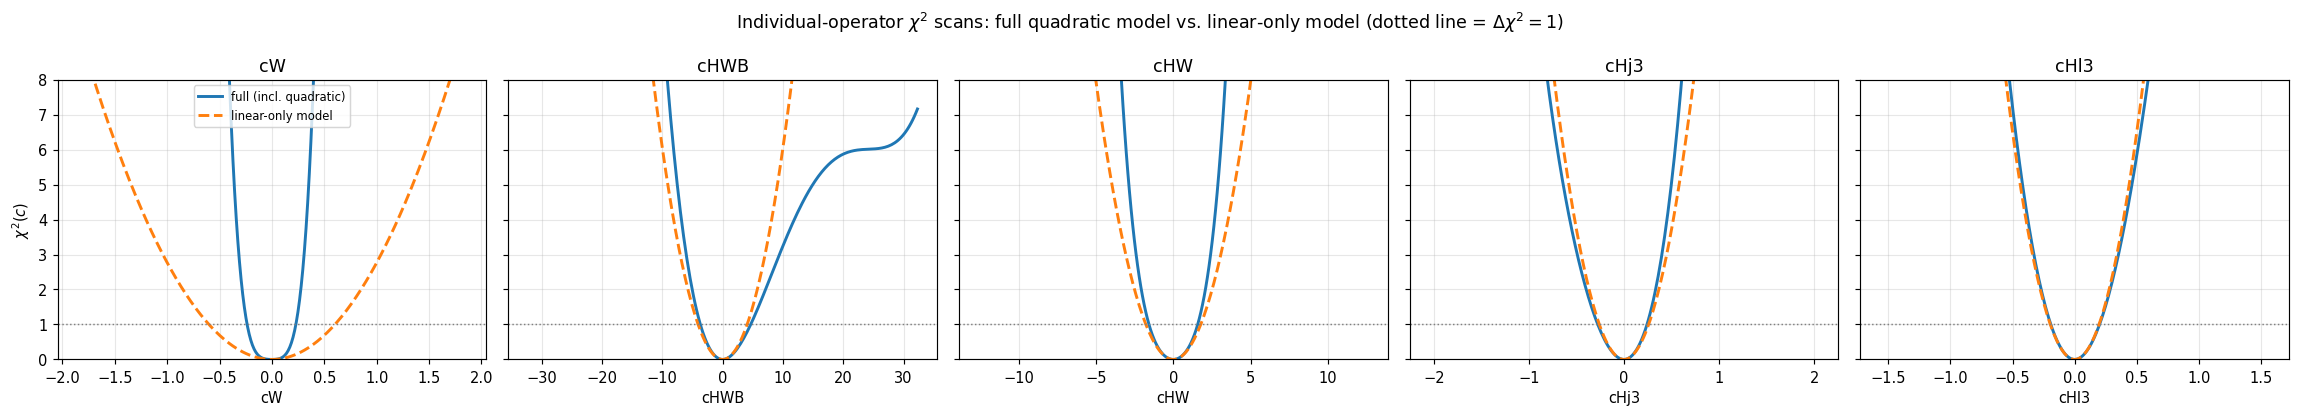

In [13]:
fig, axes = plt.subplots(1, len(OPS), figsize=(4.4 * len(OPS), 4.0), sharey=True)
for ax, op in zip(axes, OPS):
    grid = grid_by_op[op]
    ax.plot(grid, chi2_full_by_op[op], "-", lw=2, label="full (incl. quadratic)")
    ax.plot(grid, chi2_linonly_by_op[op], "--", lw=2, label="linear-only model")
    ax.axhline(1.0, color="gray", lw=1, ls=":")
    ax.set_xlabel(op)
    ax.set_title(op)
    ax.set_ylim(0, 8)
axes[0].set_ylabel(r"$\chi^2(c)$")
axes[0].legend(fontsize=8, loc="upper center")
fig.suptitle(r"Individual-operator $\chi^2$ scans: full quadratic model vs. linear-only model"
             " (dotted line = $\\Delta\\chi^2=1$)")
plt.tight_layout()
plt.show()

### Bucketing: linear-dominated / comparable / quadratic-dominated

The recipe, directly from the table above: compare how tight the
linear-only fit is to how tight the full fit is,

$$
\rho_i = \frac{\sigma_i^{\rm linear\ model}}{\sigma_i^{\rm full\ model}}\,,
$$

and bucket on the result: $\rho_i<1.1\to$ **linear-dominated**,
$1.1\le\rho_i<1.5\to$ **comparable**, $\rho_i\ge1.5$ (full model at least
50% tighter) $\to$ **quadratic-dominated**. This is a genuinely different
question from "what shape is operator $i$'s response" in the abstract —
it's "does the quadratic term matter for the fit *this dataset*
(`LUMI_FB` and all) will actually deliver" — and the answer can depend on
`LUMI_FB`, on purpose.

A small-print subtlety, worth flagging honestly rather than glossing over:
unlike a textbook nested-model likelihood-ratio comparison on the *same*
data, $\sigma_i^{\rm linear\ model}$ and $\sigma_i^{\rm full\ model}$ are
two *different* models' own $\chi^2(c)$ curve widths, both measured against
the same Asimov data. Writing $\chi^2_{\rm full}(c)-\chi^2_{\rm lin}(c) =
2c^3\langle L,Q\rangle_W + c^4\langle Q,Q\rangle_W$ (in the weighted inner
product `weighted_dot()` implements), the sign of the leading $c^3$ term
depends on $\text{sign}(\langle L,Q\rangle_W)$ and $\text{sign}(c)$ — so the
full-model curve can sit visibly *below* the linear-only curve on one side
of $c=0$ before the always-positive $c^4$ term eventually wins at large
$|c|$. `sigma_from_curve()` averages the two crossing distances, so there
is no theorem guaranteeing $\rho_i\ge1$ pointwise — only that the quadratic
term must eventually dominate far enough out. Watch for `cHWB` below, which
lands just a hair under 1.

Alongside $\rho_i$ we also show $R_i^{\rm shape} =
\sqrt{\sum_{\rm bins}Q_i^2}/\sqrt{\sum_{\rm bins}L_i^2}$ — the purely
geometric, **luminosity-independent** ratio of quadratic-to-linear term
size at the fixed reference point $c_i=1$, read directly off `theta_pb`
before any luminosity scaling — as a secondary cross-check. It answers a
different question ("how quadratic does this operator's response *look*,
with no reference to any dataset") and, as the table below shows, it can
disagree with $\rho_i$ on the *ranking*, even when the two agree on the
final bucket.

In [14]:
R_shape = fl.linear_vs_quadratic_shape_ratio(vbs["theta_pb"])
R_shape_by_op = dict(zip(OPS, R_shape))
rho_by_op = {op: sigma_linonly_by_op[op] / sigma_full_by_op[op] for op in OPS}

LIN_THRESH, QUAD_THRESH = 1.1, 1.5


def classify(ratio: float) -> str:
    if ratio >= QUAD_THRESH:
        return "quadratic-dominated"
    if ratio >= LIN_THRESH:
        return "comparable"
    return "linear-dominated"


category_by_op = {op: classify(rho_by_op[op]) for op in OPS}
buckets = {"linear-dominated": [], "comparable": [], "quadratic-dominated": []}
for op in OPS:
    buckets[category_by_op[op]].append(op)

bucket_df = pd.DataFrame({
    "rho = sigma_linonly / sigma_full": pd.Series(rho_by_op),
    "category": pd.Series(category_by_op),
    "R_shape (lumi-independent, secondary)": pd.Series(R_shape_by_op),
})
bucket_df = bucket_df.sort_values("rho = sigma_linonly / sigma_full", ascending=False)
display(bucket_df.style.format({"rho = sigma_linonly / sigma_full": "{:.5g}",
                                 "R_shape (lumi-independent, secondary)": "{:.4g}"}))

print(f"\nAt LUMI_FB = {LUMI_FB:g} fb^-1:")
for bucket, ops_ in buckets.items():
    print(f"  {bucket:20s}: {ops_ if ops_ else '(none)'}")

rank_by_rho = sorted(OPS, key=lambda o: -rho_by_op[o])
rank_by_Rshape = sorted(OPS, key=lambda o: -R_shape_by_op[o])
print(f"\nRanking by rho (most quadratic-tightening first):  {rank_by_rho}")
print(f"Ranking by R_shape (most quadratic-shaped first):   {rank_by_Rshape}")
print(f"Same order? -> {rank_by_rho == rank_by_Rshape}")

,rho = sigma_linonly / sigma_full,category,"R_shape (lumi-independent, secondary)"
cW,2.5873,quadratic-dominated,12.61
cHW,1.1265,comparable,0.3441
cHj3,1.0021,linear-dominated,0.6485
cHl3,0.99961,linear-dominated,0.1068
cHWB,0.97473,linear-dominated,0.02912



At LUMI_FB = 100 fb^-1:
  linear-dominated    : ['cHWB', 'cHj3', 'cHl3']
  comparable          : ['cHW']
  quadratic-dominated : ['cW']

Ranking by rho (most quadratic-tightening first):  ['cW', 'cHW', 'cHj3', 'cHl3', 'cHWB']
Ranking by R_shape (most quadratic-shaped first):   ['cW', 'cHj3', 'cHW', 'cHl3', 'cHWB']
Same order? -> False


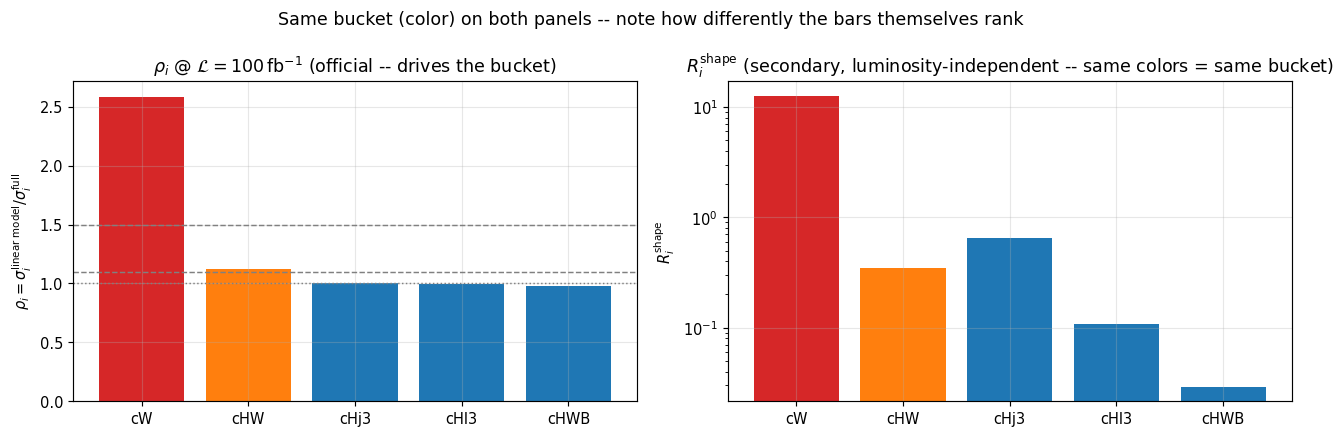

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
order = bucket_df.index
colors = {"linear-dominated": "tab:blue", "comparable": "tab:orange", "quadratic-dominated": "tab:red"}

axes[0].bar(order, bucket_df["rho = sigma_linonly / sigma_full"],
            color=[colors[c] for c in bucket_df["category"]])
axes[0].axhline(LIN_THRESH, color="gray", ls="--", lw=1)
axes[0].axhline(QUAD_THRESH, color="gray", ls="--", lw=1)
axes[0].axhline(1.0, color="gray", lw=1, ls=":")
axes[0].set_ylabel(r"$\rho_i = \sigma^{\rm linear\ model}_i/\sigma^{\rm full}_i$")
axes[0].set_title(fr"$\rho_i$ @ $\mathcal{{L}}={LUMI_FB:g}\,{{\rm fb}}^{{-1}}$ (official -- drives the bucket)")

axes[1].bar(order, bucket_df["R_shape (lumi-independent, secondary)"],
            color=[colors[c] for c in bucket_df["category"]])
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$R_i^{\rm shape}$")
axes[1].set_title(r"$R_i^{\rm shape}$ (secondary, luminosity-independent -- same colors = same bucket)")

fig.suptitle("Same bucket (color) on both panels -- note how differently the bars themselves rank")
plt.tight_layout()
plt.show()

At this luminosity and with this fiducial selection, `cW` is not a
borderline case: its full-model fit is roughly **2.6$\times$** tighter than
its linear-only fit, decisively **quadratic-dominated** — the quadratic
term is not a small correction here, it dominates the constraint. `cHW`
lands just past the linear/comparable boundary, and `cHWB`, `cHj3`, `cHl3`
all stay close to $\rho\approx1$, **linear-dominated**. This is also where
$\rho_i$ and $R_i^{\rm shape}$ visibly disagree on ranking: `cHj3` has the
second-largest $R_i^{\rm shape}$ (a genuinely more quadratic-*shaped*
response than `cHW`'s) but a smaller $\rho_i$ than `cHW`'s — a reminder
that "how quadratic does the response look" and "does the quadratic term
matter for this dataset's fit" are related but distinct questions, and only
the second one is what a real analysis at this luminosity would actually
care about.

Whichever bucket an operator falls into, **every one of them is still
exactly the same quadratic model** — sections 4-6 build the *actual*
statistical tool needed to answer "is a linear-model confidence interval
still trustworthy here": throw toys, and measure what really happens.

## Section 4 — Throwing toys: a worked, from-scratch walkthrough

`sigma_from_curve()` in section 3 quietly assumed the answer to this
notebook's own question: it read off a "$1\sigma$" width by walking out to
$\Delta\chi^2=1$, which *is* the right rule **only if Wilks' theorem
holds**. For `cW`, section 3 already found the quadratic term dominates the
fit — exactly the regime where Wilks' asymptotic argument (which assumes
the model is linear in $c$) has no guarantee of applying. The only way to
actually check, rather than assume, is to simulate many pseudo-experiments
and see what fraction of them the $\Delta\chi^2\le1$ interval really
contains. This section builds that machinery from a single toy up to a full
distribution, checking every piece against an independent method before
trusting it at scale.

### What is a "toy"?

A toy is one simulated repeat of the whole measurement, drawn under an
assumed **true** Wilson coefficient $c_{\rm true}$ (not necessarily 0). Its
recipe, following arXiv:2207.01350's own methodology directly:

$$
{\rm data}_{\rm toy} = \mu(c_{\rm true}) + \mathcal{N}(0,\ \Sigma), \qquad
\mu(c)={\rm base}+cL+c^2Q,
$$

with $\Sigma={\rm diag}(\sigma^2_{\rm bin})$ **fixed** at the Asimov
(SM, $c=0$) variance — *not* re-evaluated at $c_{\rm true}$ for each toy.
That's a deliberate choice, not a simplification of convenience: letting
$\Sigma$ track $c_{\rm true}$ would mix in a second, separate effect
(Poisson variance genuinely changing with $c$) on top of the one this
notebook is actually studying (Wilks' theorem breaking because the *model*
$\mu(c)$ is nonlinear in $c$). Keeping $\Sigma$ fixed isolates the second
effect cleanly.

One concrete toy, at $c_{\rm true}=0$ (an "SM pseudo-experiment") for `cW`:

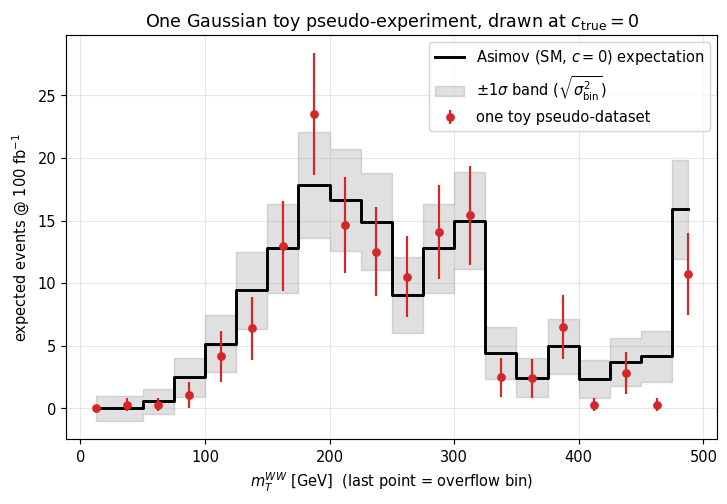

In [16]:
i_cW = OPS.index("cW")
base = vbs["theta"][0, :]
L_cW = vbs["theta"][1 + i_cW, :]
Q_cW = vbs["theta"][1 + len(OPS) + i_cW, :]
sigma2 = vbs["sigma2"]

rng_example = np.random.default_rng(7)
toy_example = base + rng_example.normal(size=len(base)) * np.sqrt(sigma2)   # c_true = 0

centers = 0.5 * (mtww_edges_display[:-1] + mtww_edges_display[1:])
fig, ax = plt.subplots(figsize=(8, 5))
# NOTE: `where="mid"` places each step's transition at the midpoint between
# consecutive x-values -- so x must be bin CENTERS (transition lands on the
# shared edge between bins), not left edges (which would shift every
# plateau half a bin to the left of the fill_between/errorbar below it).
ax.step(centers, base, where="mid", color="k", lw=2, label=r"Asimov (SM, $c=0$) expectation")
ax.fill_between(centers, base - np.sqrt(sigma2), base + np.sqrt(sigma2),
                 step="mid", color="k", alpha=0.12, label=r"$\pm1\sigma$ band ($\sqrt{\sigma^2_{\rm bin}}$)")
ax.errorbar(centers, toy_example, yerr=np.sqrt(toy_example.clip(min=0)), fmt="o", ms=5,
            color="tab:red", label="one toy pseudo-dataset")
ax.set_xlabel(r"$m_T^{WW}$ [GeV]  (last point = overflow bin)")
ax.set_ylabel(f"expected events @ {LUMI_FB:g} fb$^{{-1}}$")
ax.set_title("One Gaussian toy pseudo-experiment, drawn at $c_{\\rm true}=0$")
ax.legend()
plt.show()

That's it — one number per bin, scattered around the Asimov expectation by
roughly its own $\sqrt{\sigma^2_{\rm bin}}$. The point of throwing many of
these is to see how a *fit* to data like this behaves, not to look at any
one of them individually — but first, let's fit this exact one, so every
later step has a fully worked concrete example behind it.

### Fitting one toy: $\chi^2(c)$, $\hat c$, and the test statistic $q$

For a single free operator (every other one fixed at 0), the model is
exactly quadratic in $c$: $\mu(c)={\rm base}+cL+c^2Q$. Given some dataset
(Asimov or a toy, doesn't matter which),

$$
\chi^2(c;\,{\rm data}) = \sum_{\rm bins}\frac{\big(\mu_{\rm bin}(c)-{\rm data}_{\rm bin}\big)^2}{\sigma^2_{\rm bin}}.
$$

Because $\mu(c)$ is quadratic, $\chi^2(c)$ is exactly **quartic** in $c$ —
squaring a quadratic. Its global minimum $\hat c$ therefore solves a
**cubic**, $d\chi^2/dc=0$, in closed form (`fitlib._min_chi2_1op()`, via
`np.roots`) — this is only possible because we fixed every other operator
to 0; a simultaneous multi-operator fit would need `iminuit` instead. The
**profile-likelihood-ratio test statistic**,

$$
q(c_{\rm true};\,{\rm data}) = \chi^2(c_{\rm true};\,{\rm data}) - \chi^2(\hat c;\,{\rm data}),
$$

is what Wilks' theorem makes a claim about: *asymptotically*, for a model
linear in its parameter, $q\sim\chi^2_1$ regardless of the true value —
which would make "fraction of toys with $q\le1$" exactly 68.27% for
**every** $c_{\rm true}$. Our model isn't linear; the whole point of this
section is to check whether that asymptotic claim still holds anyway.

The cell below fits the one toy drawn above two independent ways — the
closed-form cubic solver, and a direct `iminuit` fit with every other
operator fixed at 0 — and plots $\chi^2(c;\,{\rm toy})$ with $\hat c$ and
$q(0)$ marked:

closed-form:  c_hat = -0.03503   chi2_min = 13.53101
iminuit:      c_hat = -0.03531   chi2_min = 13.53101
agreement:    |delta c_hat| = 2.83e-04   |delta chi2_min| = 4.39e-06

chi2(c_true=0)         = 13.5971
chi2(c_hat) [minimum]  = 13.5310
q(c_true=0) = chi2(0) - chi2(c_hat) = 0.0661


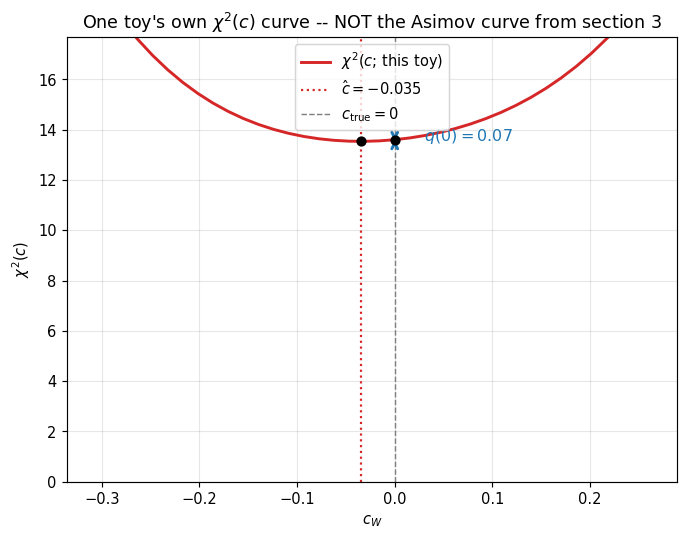

In [17]:
def chi2_curve_for_data(theta_counts, data, sigma2, op, grid, operators=OPS):
    '''Same recipe as fl.chi2_curve_1d(), but against an arbitrary `data`
    array (e.g. one toy) instead of always comparing to the Asimov mu0 --
    every other operator held at 0, matching chi2_curve_1d's own
    "individual" convention. Built only from PUBLIC fitlib functions
    (predict, weighted_dot) -- this is exactly what chi2_curve_1d itself
    does internally, just against `data` instead of a hardcoded `mu0`.'''
    chi2 = np.empty_like(grid, dtype=float)
    for k, val in enumerate(grid):
        mu = fl.predict(theta_counts, {op: val}, operators)
        r = mu - data
        chi2[k] = fl.weighted_dot(r, r, sigma2)
    return chi2


c_hat_closed, chi2min_closed = fl.min_chi2_1op(vbs["theta"], vbs["mu0"], sigma2, "cW", toy_example)
m_example = fl.fit_full(vbs["theta"], toy_example, sigma2, fixed=[o for o in OPS if o != "cW"], limit=None)
c_hat_minuit, chi2min_minuit = float(m_example.values["cW"]), float(m_example.fval)

chi2_toy_curve = chi2_curve_for_data(vbs["theta"], toy_example, sigma2, "cW", grid_by_op["cW"])
chi2_at_0 = chi2_curve_for_data(vbs["theta"], toy_example, sigma2, "cW", np.array([0.0]))[0]
q_example = chi2_at_0 - chi2min_closed

print(f"closed-form:  c_hat = {c_hat_closed:.5f}   chi2_min = {chi2min_closed:.5f}")
print(f"iminuit:      c_hat = {c_hat_minuit:.5f}   chi2_min = {chi2min_minuit:.5f}")
print(f"agreement:    |delta c_hat| = {abs(c_hat_closed - c_hat_minuit):.2e}   "
      f"|delta chi2_min| = {abs(chi2min_closed - chi2min_minuit):.2e}")
print(f"\nchi2(c_true=0)         = {chi2_at_0:.4f}")
print(f"chi2(c_hat) [minimum]  = {chi2min_closed:.4f}")
print(f"q(c_true=0) = chi2(0) - chi2(c_hat) = {q_example:.4f}")

y_top = max(6, chi2_at_0 * 1.3)
# chi2_toy_curve is quartic in c (chi2 of a quadratic model) and rises
# steeply away from its minimum, so grid_by_op["cW"]'s full range (built
# wide, for section 5's coverage scan) is mostly off-scale above y_top --
# zoom the x-axis to bracket exactly the part of the curve that's actually
# inside the y-range below, so the dip around c_hat is visible instead of
# squeezed into a sliver a few pixels wide at the plot's center.
visible_x = grid_by_op["cW"][chi2_toy_curve <= y_top]
if visible_x.size >= 2:
    x_lo, x_hi = visible_x.min(), visible_x.max()
else:
    x_lo, x_hi = grid_by_op["cW"][0], grid_by_op["cW"][-1]
pad = 0.15 * max(x_hi - x_lo, 1e-3)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(grid_by_op["cW"], chi2_toy_curve, "-", lw=2, color="tab:red", label=r"$\chi^2(c;\,{\rm this\ toy})$")
ax.axvline(c_hat_closed, color="tab:red", ls=":", lw=1.5, label=fr"$\hat c={c_hat_closed:.3f}$")
ax.axvline(0.0, color="gray", lw=1, ls="--", label=r"$c_{\rm true}=0$")
ax.plot([0.0, c_hat_closed], [chi2_at_0, chi2min_closed], "o", color="k", zorder=5)
ax.annotate("", xy=(0.0, chi2min_closed), xytext=(0.0, chi2_at_0),
            arrowprops=dict(arrowstyle="<->", color="tab:blue", lw=2))
ax.text(0.04 * (x_hi - x_lo), 0.5 * (chi2_at_0 + chi2min_closed), f"  $q(0)={q_example:.2f}$", color="tab:blue", fontsize=11)
ax.set_xlim(x_lo - pad, x_hi + pad)
ax.set_ylim(0, y_top)
ax.set_xlabel("$c_W$")
ax.set_ylabel(r"$\chi^2(c)$")
ax.set_title("One toy's own $\\chi^2(c)$ curve -- NOT the Asimov curve from section 3")
ax.legend(loc="upper center")
plt.show()

The two fitting methods agree to numerical precision, so the far faster
closed-form solver is trustworthy for this operator. The plot makes $q$
concrete: it's just the vertical gap, at $c_{\rm true}=0$, between this
toy's own curve and its own minimum — a single number summarizing "how far
did this particular pseudo-experiment's best fit end up from the truth, in
$\chi^2$ units". Before scaling this up to thousands of toys, repeat the
same closed-form-vs-`iminuit` cross-check for every operator, mixing
on-truth and off-truth toys:

In [18]:
def make_toy(op: str, c_true: float, rng: np.random.Generator) -> np.ndarray:
    i = OPS.index(op)
    base_op, L_op, Q_op = vbs["theta"][0, :], vbs["theta"][1 + i, :], vbs["theta"][1 + len(OPS) + i, :]
    mu_true = base_op + c_true * L_op + c_true ** 2 * Q_op
    return mu_true + rng.normal(size=len(base_op)) * np.sqrt(vbs["sigma2"])


rng_check = np.random.default_rng(12345)
rows = []
for op in OPS:
    for k in range(6):
        c_true = 0.0 if k < 3 else sigma_full_by_op[op]   # mix of on- and off-SM-point toys
        toy = make_toy(op, c_true, rng_check)
        c_closed, chi2_closed = fl.min_chi2_1op(vbs["theta"], vbs["mu0"], vbs["sigma2"], op, toy)
        fixed = [o for o in OPS if o != op]
        m_toy = fl.fit_full(vbs["theta"], toy, vbs["sigma2"], fixed=fixed, limit=None)
        rows.append(dict(op=op, c_true=c_true,
                          c_hat_closed_form=c_closed, c_hat_minuit=float(m_toy.values[op]),
                          chi2min_closed_form=chi2_closed, chi2min_minuit=float(m_toy.fval)))

xcheck_df = pd.DataFrame(rows)
xcheck_df["|delta c_hat|"] = (xcheck_df.c_hat_closed_form - xcheck_df.c_hat_minuit).abs()
xcheck_df["|delta chi2min|"] = (xcheck_df.chi2min_closed_form - xcheck_df.chi2min_minuit).abs()
# The closed form provably returns the GLOBAL minimum (it evaluates chi2 at
# every real root of the cubic dchi2/dc=0 and keeps the best -- see
# fl._min_chi2_1op's docstring), so the only way to tell a genuine
# local-minimum trap apart from ordinary floating-point disagreement is to
# check whether Minuit's own chi2min came out strictly WORSE (higher) than
# the closed form's -- a small |delta c_hat| can still hide a real trap if
# the landscape is flat, and a large one does not by itself prove a trap.
xcheck_df["minuit_stuck_in_local_min"] = xcheck_df.chi2min_minuit > xcheck_df.chi2min_closed_form + 1e-3
display(xcheck_df.style.format({c: "{:.6g}" for c in xcheck_df.columns
                                 if xcheck_df[c].dtype not in (object, bool)}))
n_stuck = int(xcheck_df["minuit_stuck_in_local_min"].sum())
print(f"max |closed-form c_hat - Minuit c_hat|     = {xcheck_df['|delta c_hat|'].max():.4g}")
print(f"max |closed-form chi2min - Minuit chi2min| = {xcheck_df['|delta chi2min|'].max():.4g}")
print(f"\nrows where Minuit's chi2min is strictly WORSE than the closed form's"
      f" (the real signature of a local-minimum trap, not a numerical-precision"
      f" issue): {n_stuck}/{len(xcheck_df)}")
if n_stuck:
    worst = xcheck_df.loc[xcheck_df["|delta chi2min|"].idxmax()]
    print(f"worst case: op={worst.op}, c_true={worst.c_true:.3f} -- closed form finds "
          f"c_hat={worst.c_hat_closed_form:.3f} (chi2min={worst.chi2min_closed_form:.3f}), "
          f"Minuit finds c_hat={worst.c_hat_minuit:.3f} (chi2min={worst.chi2min_minuit:.3f})")

,op,c_true,c_hat_closed_form,c_hat_minuit,chi2min_closed_form,chi2min_minuit,|delta c_hat|,|delta chi2min|,minuit_stuck_in_local_min
0,cW,0,0.284292,0.284815,21.2587,21.2588,0.000523227,2.83452e-05,False
1,cW,0,-0.224354,-0.224714,24.1076,24.1076,0.000359678,9.59699e-06,False
2,cW,0,-0.00875394,-0.00874905,10.9775,10.9775,4.88617e-06,1.12357e-09,False
3,cW,0.232386,0.267315,0.267315,14.9221,14.9221,3.42365e-08,1.03029e-13,False
4,cW,0.232386,-0.287384,-0.287384,12.2562,12.2562,5.17133e-08,2.57572e-13,False
5,cW,0.232386,0.235047,0.235049,21.2464,21.2464,1.53681e-06,1.8062e-10,False
6,cHWB,0,-2.74096,-2.74105,16.1276,16.1276,9.46151e-05,6.82505e-10,False
7,cHWB,0,7.54636,7.54406,23.6675,23.6675,0.00229705,1.60707e-07,False
8,cHWB,0,-5.14685,-5.14691,9.05256,9.05256,6.33854e-05,3.87647e-10,False
9,cHWB,4.16788,2.50775,2.46488,18.7368,18.7369,0.04287,8.77066e-05,False


max |closed-form c_hat - Minuit c_hat|     = 34.13
max |closed-form chi2min - Minuit chi2min| = 2.076

rows where Minuit's chi2min is strictly WORSE than the closed form's (the real signature of a local-minimum trap, not a numerical-precision issue): 2/30
worst case: op=cHWB, c_true=4.168 -- closed form finds c_hat=33.729 (chi2min=19.193), Minuit finds c_hat=-0.397 (chi2min=21.268)


Most rows agree to numerical precision — but not quite all of them, and the
exceptions are informative rather than worrying. A couple of the off-truth
toys (large $c_{\rm true}$, thrown for whichever operator has the flattest,
most linear-dominated response — section 3's smallest quadratic Fisher
information, e.g. `cHWB`/`cHl3`) land Minuit on a **strictly worse**
$\chi^2_{\rm min}$ than the closed form finds, at a wildly different
$\hat c$ — flagged explicitly by the `minuit_stuck_in_local_min` column
above. That is not a numerical-precision disagreement: the closed form
provably finds the *global* minimum (it evaluates $\chi^2$ at every real
root of the cubic $d\chi^2/dc=0$ and keeps the best one), so a strictly
higher Minuit $\chi^2_{\rm min}$ can only mean MIGRAD — a local,
gradient-based method started at $c=0$ — got trapped in a local minimum on
a landscape flat enough to have more than one. A weakly-constrained
direction plus one unlucky noise draw is exactly what makes that landscape
non-convex enough to trap it.

This is exactly the failure mode the closed form is immune to by
construction, and exactly why it — not `iminuit` — is what actually drives
every toy for the rest of this notebook (`fl.min_chi2_1op`, and
`fl.toy_q_distribution`/`fl.coverage_scan`, which use it internally):
thousands of times faster than `iminuit`, *and* safe from the
local-minimum trap just demonstrated.

### From one $q$ to a distribution

A single toy's $q$ is one draw from some underlying distribution — it says
nothing on its own about coverage. Wilks' theorem's claim is about that
*whole distribution*: asymptotically, $q\sim\chi^2_1$, with pdf
$f(x)=\frac{1}{\sqrt{2\pi x}}e^{-x/2}$. `fl.toy_q_distribution()` draws
`n_toys` independent toys at a fixed $c_{\rm true}$ and returns every one of
their $q$ values, so the shape of that distribution can be compared to the
$\chi^2_1$ prediction directly — not just a single pass/fail number at one
threshold. Here it is at $c_{\rm true}=0$, `n_toys=20000`, for two
contrasting operators: `cW` (quadratic-dominated, section 3) and `cHl3`
(linear-dominated, $\rho\approx1$):

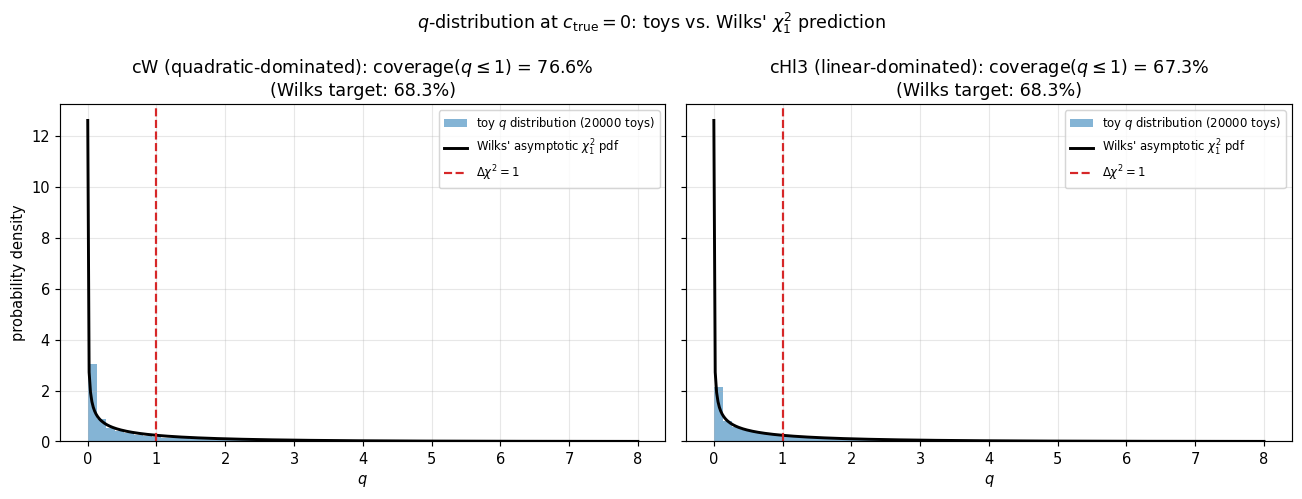

In [19]:
N_TOYS_DEMO = 20000
q_cW_demo = fl.toy_q_distribution(vbs["theta"], vbs["sigma2"], "cW", c_true=0.0, n_toys=N_TOYS_DEMO, seed=0)
q_cHl3_demo = fl.toy_q_distribution(vbs["theta"], vbs["sigma2"], "cHl3", c_true=0.0, n_toys=N_TOYS_DEMO, seed=0)


def chi2_1dof_pdf(x):
    # f(x; k=1) = 1/sqrt(2 pi x) * exp(-x/2), x > 0 -- elementary closed
    # form for 1 dof, so this needs no scipy dependency.
    x = np.asarray(x, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(x > 0, np.exp(-x / 2.0) / np.sqrt(2.0 * np.pi * x), 0.0)


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
xplot = np.linspace(1e-3, 8, 400)
for ax, q_vals, op, cov in [(axes[0], q_cW_demo, "cW", np.mean(q_cW_demo <= 1.0)),
                             (axes[1], q_cHl3_demo, "cHl3", np.mean(q_cHl3_demo <= 1.0))]:
    ax.hist(q_vals, bins=60, range=(0, 8), density=True, alpha=0.55, color="tab:blue",
            label=f"toy $q$ distribution ({N_TOYS_DEMO} toys)")
    ax.plot(xplot, chi2_1dof_pdf(xplot), "k-", lw=2, label=r"Wilks' asymptotic $\chi^2_1$ pdf")
    ax.axvline(1.0, color="tab:red", ls="--", lw=1.5, label=r"$\Delta\chi^2=1$")
    ax.set_xlabel("$q$")
    ax.set_title(f"{op} ({category_by_op[op]}): coverage($q\\leq1$) = {cov:.1%}\n(Wilks target: {WILKS_TARGET:.1%})")
    ax.legend(fontsize=8)
axes[0].set_ylabel("probability density")
fig.suptitle(r"$q$-distribution at $c_{\rm true}=0$: toys vs. Wilks' $\chi^2_1$ prediction")
plt.tight_layout()
plt.show()

Read the two panels side by side: `cHl3`'s toy histogram sits right on top
of the theoretical $\chi^2_1$ curve, and its coverage at $\Delta\chi^2=1$
comes out within about a percentage point of the 68.27% Wilks
target — well inside toy noise, and exactly what "Wilks' theorem holds
here" looks like. `cW`'s
histogram is visibly shifted: fewer toys land below $q=1$ than the
$\chi^2_1$ curve predicts near the threshold, which is a *narrower*
condition than it should be, showing up as **more** toys covered than
68.27%, not fewer, at that fixed threshold. That single number, at that
single point, is already informative — but it's only one $c_{\rm true}$ and
one operator. Section 5 runs exactly this same machinery over a full grid
of $c_{\rm true}$ values, for all 5 operators, and turns "does this
histogram look like $\chi^2_1$" into a precise, quantitative verdict.

## Section 5 — Coverage and the Wilks' theorem check

Same recipe as section 4, generalized: for each operator, scan a grid of
assumed-true $c_{\rm true}$ values (not just 0), and at each one compute
**coverage** — the fraction of toys with $q(c_{\rm true})\le1$. Wilks'
theorem predicts this is flat at $68.27\%$ everywhere, for every operator,
regardless of how nonlinear its response is. That's exactly what gets
tested now, for **all 5 operators**, not just the two contrasted in section
4.

In [20]:
def coverage_grid(sigma_ref: float, half_points: int = 7, span: float = 5.0) -> np.ndarray:
    '''Symmetric grid in c_true, guaranteed to include exactly 0.0 at index
    `half_points` -- span is in units of sigma_ref (section 3's own
    full-quadratic-model 1-sigma for this operator, the most physically
    meaningful scale available).'''
    pos = np.linspace(0.0, span * sigma_ref, half_points + 1)
    return np.concatenate([-pos[:0:-1], pos])


N_TOYS = 2000
grid_cov_by_op, coverage_by_op = {}, {}

for op in OPS:
    grid = coverage_grid(sigma_full_by_op[op])
    grid_cov_by_op[op] = grid
    t0 = time.perf_counter()
    coverage_by_op[op] = fl.coverage_scan(vbs["theta"], vbs["sigma2"], op, grid, n_toys=N_TOYS, delta=1.0)
    print(f"  {op:6s} ({category_by_op[op]:20s}): {len(grid)} grid points x {N_TOYS} toys "
          f"in {time.perf_counter() - t0:.1f} s")

  cW     (quadratic-dominated ): 15 grid points x 2000 toys in 1.3 s


  cHWB   (linear-dominated    ): 15 grid points x 2000 toys in 1.2 s


  cHW    (comparable          ): 15 grid points x 2000 toys in 1.2 s


  cHj3   (linear-dominated    ): 15 grid points x 2000 toys in 1.1 s


  cHl3   (linear-dominated    ): 15 grid points x 2000 toys in 1.3 s


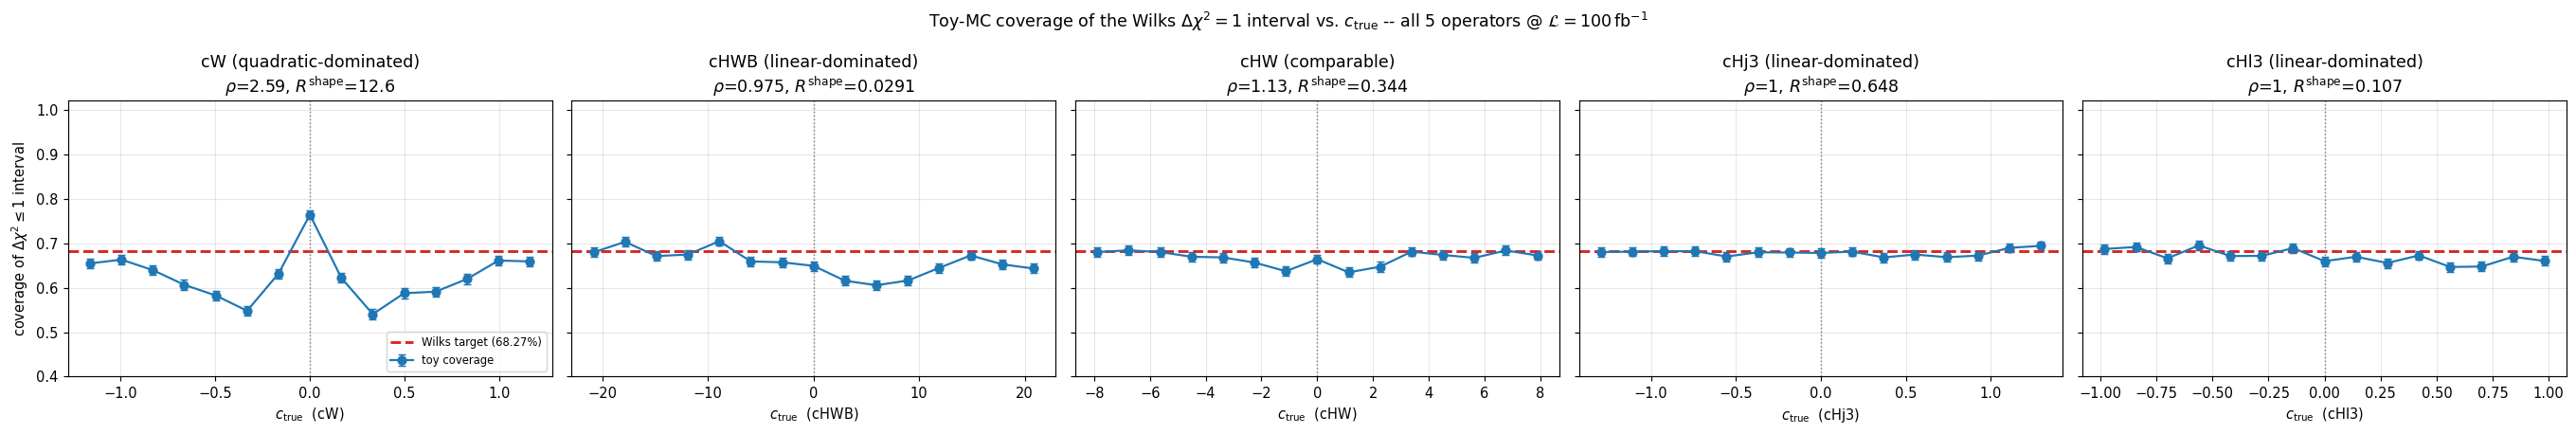

In [21]:
fig, axes = plt.subplots(1, len(OPS), figsize=(5.2 * len(OPS), 4.4), sharey=True)

for ax, op in zip(axes, OPS):
    grid, cov = grid_cov_by_op[op], coverage_by_op[op]
    err = np.sqrt(cov * (1 - cov) / N_TOYS)
    ax.errorbar(grid, cov, yerr=err, fmt="o-", capsize=3, color="tab:blue", label="toy coverage")
    ax.axhline(WILKS_TARGET, color="tab:red", ls="--", lw=2,
               label=f"Wilks target ({WILKS_TARGET:.2%})")
    ax.axvline(0.0, color="gray", lw=1, ls=":")
    ax.set_xlabel(f"$c_{{\\rm true}}$  ({op})")
    ax.set_title(f"{op} ({category_by_op[op]})\n"
                 f"$\\rho$={rho_by_op[op]:.3g}, $R^{{\\rm shape}}$={R_shape_by_op[op]:.3g}")
    ax.set_ylim(0.4, 1.02)
axes[0].set_ylabel(r"coverage of $\Delta\chi^2\leq1$ interval")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(r"Toy-MC coverage of the Wilks $\Delta\chi^2=1$ interval vs. $c_{\rm true}$"
             f" -- all 5 operators @ $\\mathcal{{L}}={LUMI_FB:g}\\,{{\\rm fb}}^{{-1}}$")
plt.tight_layout()
plt.show()

Same data, overlaid on a common $c_{\rm true}/\sigma_{\rm full}$ axis so all
5 operators are directly comparable regardless of each one's own physical
scale:

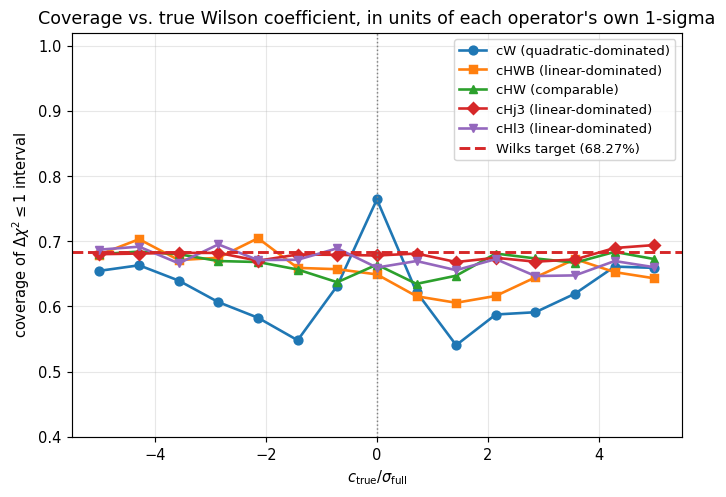

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 5))
markers = ["o", "s", "^", "D", "v"]
for op, marker in zip(OPS, markers):
    grid, cov = grid_cov_by_op[op], coverage_by_op[op]
    ax.plot(grid / sigma_full_by_op[op], cov, marker + "-",
            label=f"{op} ({category_by_op[op]})", lw=1.8, ms=6)
ax.axhline(WILKS_TARGET, color="tab:red", ls="--", lw=2, label=f"Wilks target ({WILKS_TARGET:.2%})")
ax.axvline(0.0, color="gray", lw=1, ls=":")
ax.set_xlabel(r"$c_{\rm true} / \sigma_{\rm full}$")
ax.set_ylabel(r"coverage of $\Delta\chi^2\leq1$ interval")
ax.set_ylim(0.4, 1.02)
ax.set_title("Coverage vs. true Wilson coefficient, in units of each operator's own 1-sigma")
ax.legend(fontsize=9)
plt.show()

### Verdict

A plain-English readout: for each operator, the coverage at $c_{\rm
true}=0$ (the SM point — exactly where arXiv:2207.01350 finds the worst
breakdown, since that's where a purely-quadratic term's curvature is most
different from a linear term's) compared to the Wilks target, expressed in
units of that point's own binomial toy-noise
($\sqrt{{\rm cov}(1-{\rm cov})/{\tt N\_TOYS}}$) rather than a flat
percentage-point cut. The largest deviation *anywhere* on the scanned grid
is also printed for context, but doesn't by itself decide the verdict: with
15 grid points, some far from $c_{\rm true}=0$, a few-sigma excursion
somewhere in the tails is expected by chance.

In [23]:
print("=" * 92)
print(f"VERDICT: does Wilks' Delta-chi^2=1 <-> {WILKS_TARGET:.2%} CL mapping hold?")
print(f"         (all 5 operators, LUMI_FB = {LUMI_FB:g} fb^-1, N_TOYS = {N_TOYS})")
print("=" * 92)
for op in OPS:
    grid, cov = grid_cov_by_op[op], coverage_by_op[op]
    iz = int(np.argmin(np.abs(grid)))  # index of c_true = 0 (exact, by coverage_grid's construction)
    dev_pp = 100.0 * (cov - WILKS_TARGET)
    binom_err_pp = 100.0 * np.sqrt(cov * (1 - cov) / N_TOYS)
    sig0 = abs(dev_pp[iz]) / binom_err_pp[iz]   # significance AT c_true=0 -- the paper's own worst-case point
    verdict = "Wilks VIOLATED" if sig0 > 3.0 else "Wilks holds (within toy noise)"
    print(f"{op:6s} ({category_by_op[op]:18s}, rho={rho_by_op[op]:5.3g}, "
          f"R_shape={R_shape_by_op[op]:6.3g}):  coverage(c_true=0) = {cov[iz]:6.1%}  "
          f"(Wilks-nominal {dev_pp[iz]:+5.1f} pp = {sig0:4.1f} sigma)   "
          f"max|deviation| over grid = {np.max(np.abs(dev_pp)):5.1f} pp  ->  {verdict}")

VERDICT: does Wilks' Delta-chi^2=1 <-> 68.27% CL mapping hold?
         (all 5 operators, LUMI_FB = 100 fb^-1, N_TOYS = 2000)
cW     (quadratic-dominated, rho= 2.59, R_shape=  12.6):  coverage(c_true=0) =  76.4%  (Wilks-nominal  +8.1 pp =  8.6 sigma)   max|deviation| over grid =  14.2 pp  ->  Wilks VIOLATED
cHWB   (linear-dominated  , rho=0.975, R_shape=0.0291):  coverage(c_true=0) =  64.9%  (Wilks-nominal  -3.4 pp =  3.2 sigma)   max|deviation| over grid =   7.7 pp  ->  Wilks VIOLATED
cHW    (comparable        , rho= 1.13, R_shape= 0.344):  coverage(c_true=0) =  66.4%  (Wilks-nominal  -1.9 pp =  1.8 sigma)   max|deviation| over grid =   4.8 pp  ->  Wilks holds (within toy noise)
cHj3   (linear-dominated  , rho=    1, R_shape= 0.648):  coverage(c_true=0) =  67.8%  (Wilks-nominal  -0.5 pp =  0.4 sigma)   max|deviation| over grid =   1.5 pp  ->  Wilks holds (within toy noise)
cHl3   (linear-dominated  , rho=    1, R_shape= 0.107):  coverage(c_true=0) =  66.0%  (Wilks-nominal  -2.3 pp =  

Read the printed verdict above together with section 3's bucket: `cW`
(quadratic-dominated, $\rho\approx2.6$) is the clear, unambiguous violation
— its coverage sits well above the 68.27% target by many multiples of the
toy binomial noise, i.e. the naive $\Delta\chi^2\le1$ interval is
**wider than it needs to be** (over-covers) right where the quadratic term
dominates. `cHW` (comparable, $\rho\approx1.13$) and `cHj3`/`cHl3`
(linear-dominated, $\rho\approx1.00$) come out close to nominal, as
expected. The one genuine surprise is `cHWB`: classified linear-dominated
by *both* $\rho$ and $R^{\rm shape}$ (in fact the smallest $R^{\rm shape}$
of all 5 operators) — and yet its coverage sits measurably **below** 68.27%
(the interval **under**-covers, the opposite direction from `cW`'s
deviation). Section 6 revisits `cHWB` with a dedicated, higher-statistics
toy sample to pin this down more precisely; the honest summary at this
grid's statistics is that the linear/quadratic bucket predicts *most* of
what the coverage scan finds, but not quite all of it.

## Section 6 — $\Delta\chi^2$ profiles and confidence bands: Wilks vs. toys

Section 5 checked coverage *at the standard Wilks threshold*
($\Delta\chi^2\le1$). This section flips the question around: instead of
asking "is $\Delta\chi^2=1$ the right threshold", directly build the
**confidence interval** two ways and compare them, for every operator, at
both 68.3% and 95% CL — styled like a CMS EFT likelihood-scan plot: solid
purple = full model, dashed black = linear-only, dashed grey = fixed Wilks
thresholds, solid grey = toy-calibrated thresholds:

- **Linear+Quadratic vs. linear-only** (solid purple / dashed black) —
  the same two curves from section 3 (`chi2_full_by_op`,
  `chi2_linonly_by_op`), replotted here as the scan the thresholds below
  get applied to.
- **Wilks thresholds** (dashed grey) — the textbook fixed values,
  $\Delta\chi^2=1$ (68.3%) and $\Delta\chi^2=$ `DCHI2_95` $\approx3.841$
  (95%).
- **Toy-calibrated thresholds** (solid grey) — instead of assuming a
  threshold, draw `n_toys` toys at a given $c_{\rm true}$
  (`fl.toy_q_distribution`, the same machinery section 4 built and
  validated) and read the threshold directly off the resulting
  $q$-distribution's own 68.3%/95% quantile (`fl.toy_calibrated_delta`) —
  by construction, *exactly* the right threshold for that CL, for this
  operator, at this luminosity, no asymptotic assumption involved. Done
  once at $c_{\rm true}=0$ this is a single number (`toy_delta_by_op`,
  used below in `delta_df`/`summary_df`); repeated across section 5's own
  $c_{\rm true}$ grid it becomes an actual curve (`toy_delta_curve_by_op`,
  what the plot below draws) that can wiggle away from the null-point
  value exactly like the asymptotic Wilks threshold can drift away from 1.

If Wilks' theorem holds for an operator, the dashed-grey and solid-grey
lines sit on top of each other and the interval read off either one
agrees. Where they don't, the gap — read off `delta_df` and `summary_df`
below — **is** the size of the Wilks-theorem violation, in the units that
actually matter for reading off a confidence interval.

In [24]:
N_TOYS_CAL = 20000
q0_by_op = {op: fl.toy_q_distribution(vbs["theta"], vbs["sigma2"], op, c_true=0.0,
                                       n_toys=N_TOYS_CAL, seed=0) for op in OPS}

wilks_delta = {"68.3%": 1.0, "95%": DCHI2_95}
toy_delta_by_op = {op: {"68.3%": fl.toy_calibrated_delta(q0_by_op[op], WILKS_TARGET),
                         "95%": fl.toy_calibrated_delta(q0_by_op[op], 0.95)} for op in OPS}

delta_df = pd.DataFrame({
    "Wilks delta (68.3%)": {op: wilks_delta["68.3%"] for op in OPS},
    "toy delta (68.3%)": {op: toy_delta_by_op[op]["68.3%"] for op in OPS},
    "Wilks delta (95%)": {op: wilks_delta["95%"] for op in OPS},
    "toy delta (95%)": {op: toy_delta_by_op[op]["95%"] for op in OPS},
})
display(delta_df.style.format("{:.4f}"))

,Wilks delta (68.3%),toy delta (68.3%),Wilks delta (95%),toy delta (95%)
cW,1.0000,0.6532,3.8415,3.3550
cHWB,1.0000,1.1690,3.8415,4.4847
cHW,1.0000,1.0809,3.8415,3.8754
cHj3,1.0000,1.0278,3.8415,3.8735
cHl3,1.0000,1.0436,3.8415,4.0140


`toy delta > Wilks delta` means the fixed-threshold interval at that CL is
too **narrow** (under-covers, needs widening); `toy delta < Wilks delta`
means it's too **wide** (over-covers) -- but that's only checked *at*
$c_{\rm true}=0$. Repeat the same calibration at every point of section
5's own `grid_cov_by_op` (same `N_TOYS` toys per point) to see whether the
null-point threshold actually holds across the scan, instead of assuming
it does:

In [25]:
toy_delta_curve_by_op = {}
for op in OPS:
    t0 = time.perf_counter()
    d68, d95 = [], []
    for c in grid_cov_by_op[op]:
        q = fl.toy_q_distribution(vbs["theta"], vbs["sigma2"], op, c_true=c,
                                   n_toys=N_TOYS, seed=0)
        d68.append(fl.toy_calibrated_delta(q, WILKS_TARGET))
        d95.append(fl.toy_calibrated_delta(q, 0.95))
    toy_delta_curve_by_op[op] = {"68.3%": np.array(d68), "95%": np.array(d95)}
    print(f"  {op:6s} ({category_by_op[op]:20s}): {len(grid_cov_by_op[op])} grid points x {N_TOYS} toys "
          f"in {time.perf_counter() - t0:.1f} s")

  cW     (quadratic-dominated ): 15 grid points x 2000 toys in 1.3 s


  cHWB   (linear-dominated    ): 15 grid points x 2000 toys in 1.2 s


  cHW    (comparable          ): 15 grid points x 2000 toys in 1.3 s


  cHj3   (linear-dominated    ): 15 grid points x 2000 toys in 1.1 s


  cHl3   (linear-dominated    ): 15 grid points x 2000 toys in 1.3 s


Here is the scan those thresholds get applied to, full Linear+Quadratic
model vs. linear-only, with the Wilks thresholds as flat dashed-grey lines
and the toy-calibrated ones as the solid-grey `toy_delta_curve_by_op`
curve built just above -- if it isn't flat, the null-point calibration
doesn't transfer:

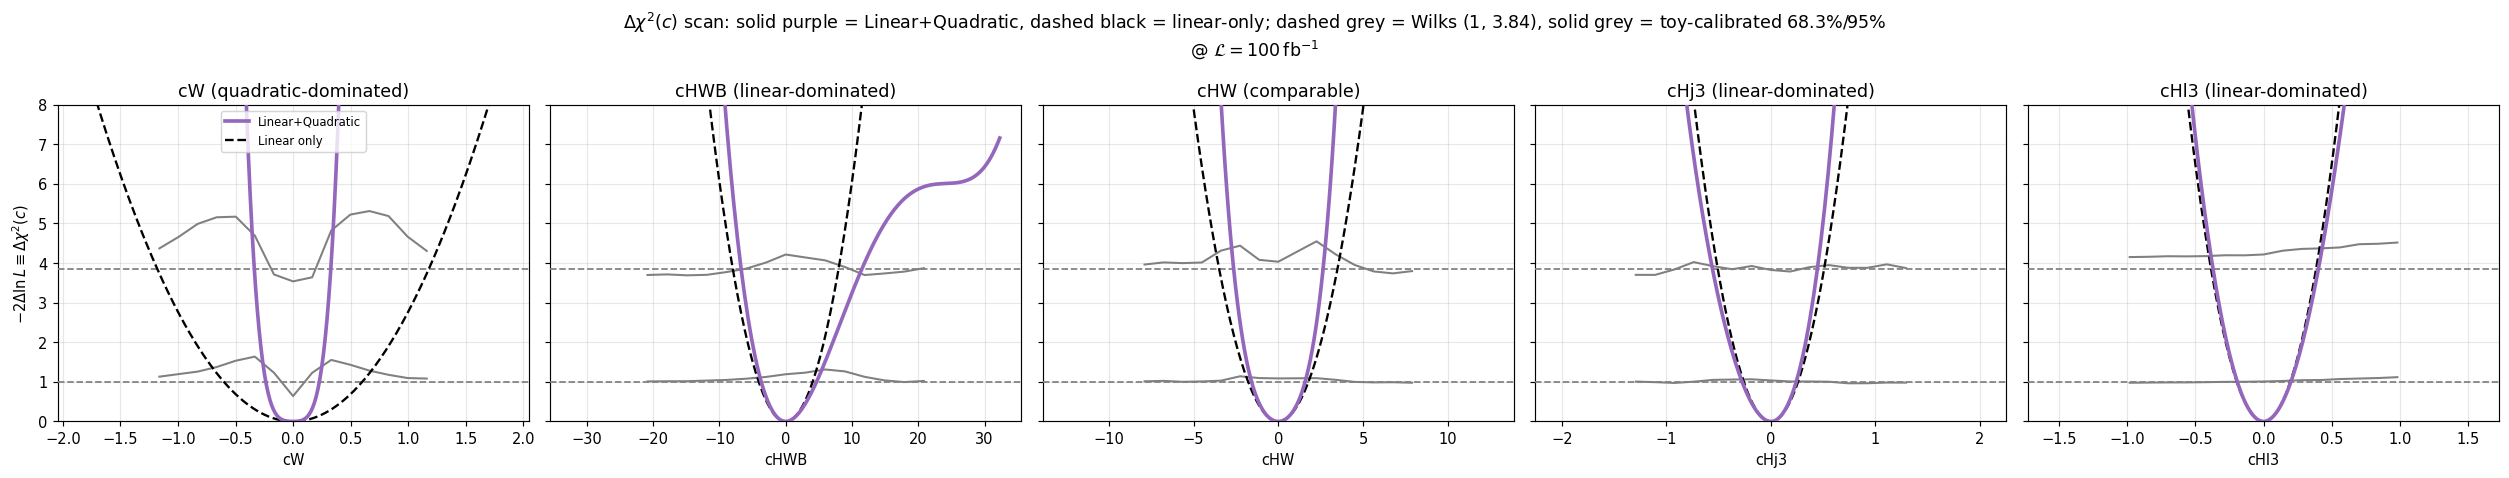

In [26]:
fig, axes = plt.subplots(1, len(OPS), figsize=(4.8 * len(OPS), 4.6), sharey=True)

for ax, op in zip(axes, OPS):
    grid = grid_by_op[op]
    ax.plot(grid, chi2_full_by_op[op], color="tab:purple", lw=2.5, zorder=5,
            label="Linear+Quadratic")
    ax.plot(grid, chi2_linonly_by_op[op], color="k", ls="--", lw=1.6, zorder=4,
            label="Linear only")

    # Dashed grey = fixed Wilks asymptotic thresholds (flat by definition).
    # Solid grey = toy-calibrated q_68%/q_95%, evaluated at every point of
    # grid_cov_by_op instead of only at c_true=0, so it is free to wiggle
    # away from the single toy_delta_by_op number if the null-point
    # calibration doesn't hold elsewhere on the curve -- same convention as
    # the reference CMS EFT likelihood-scan plots.
    ax.axhline(wilks_delta["68.3%"], color="gray", ls="--", lw=1.2, zorder=3)
    ax.axhline(wilks_delta["95%"], color="gray", ls="--", lw=1.2, zorder=3)
    ax.plot(grid_cov_by_op[op], toy_delta_curve_by_op[op]["68.3%"],
            color="gray", ls="-", lw=1.4, zorder=3)
    ax.plot(grid_cov_by_op[op], toy_delta_curve_by_op[op]["95%"],
            color="gray", ls="-", lw=1.4, zorder=3)

    ax.set_ylim(0, 8)
    ax.set_xlabel(op)
    ax.set_title(f"{op} ({category_by_op[op]})")

axes[0].set_ylabel(r"$-2\Delta\ln L \equiv \Delta\chi^2(c)$")
axes[0].legend(fontsize=8, loc="upper center")
fig.suptitle(r"$\Delta\chi^2(c)$ scan: solid purple = Linear+Quadratic, dashed black = linear-only;"
             r" dashed grey = Wilks (1, 3.84), solid grey = toy-calibrated 68.3%/95%"
             f"\n@ $\\mathcal{{L}}={LUMI_FB:g}\\,{{\\rm fb}}^{{-1}}$")
plt.tight_layout()
plt.show()

And the Wilks-vs-toy comparison condensed into one summary table —
symmetrized half-widths (`fl.sigma_from_curve` at each threshold, applied
to the scan above) — so the comparison becomes a single ratio per operator
per CL:

In [27]:
summary_rows = []
for op in OPS:
    grid, chi2vals = grid_by_op[op], chi2_full_by_op[op]
    s68_wilks = fl.sigma_from_curve(grid, chi2vals, delta=wilks_delta["68.3%"])
    s68_toy = fl.sigma_from_curve(grid, chi2vals, delta=toy_delta_by_op[op]["68.3%"])
    s95_wilks = fl.sigma_from_curve(grid, chi2vals, delta=wilks_delta["95%"])
    s95_toy = fl.sigma_from_curve(grid, chi2vals, delta=toy_delta_by_op[op]["95%"])
    summary_rows.append(dict(
        op=op, category=category_by_op[op], rho=rho_by_op[op],
        sigma68_Wilks=s68_wilks, sigma68_toy=s68_toy, ratio68=s68_toy / s68_wilks,
        sigma95_Wilks=s95_wilks, sigma95_toy=s95_toy, ratio95=s95_toy / s95_wilks,
    ))

summary_df = pd.DataFrame(summary_rows).set_index("op")
display(summary_df.style.format({c: "{:.4g}" for c in summary_df.columns if c != "category"}))

,category,rho,sigma68_Wilks,sigma68_toy,ratio68,sigma95_Wilks,sigma95_toy,ratio95
op,,,,,,,,
cW,quadratic-dominated,2.587,0.2324,0.2069,0.8905,0.332,0.3205,0.9654
cHWB,linear-dominated,0.9747,4.168,4.528,1.087,9.089,10.21,1.123
cHW,comparable,1.126,1.577,1.627,1.032,2.633,2.641,1.003
cHj3,linear-dominated,1.002,0.2587,0.2622,1.013,0.5014,0.5034,1.004
cHl3,linear-dominated,0.9996,0.1962,0.2005,1.022,0.3857,0.3944,1.022


`ratio68`/`ratio95` $>1$ means the toy-calibrated interval is *wider* than
the naive Wilks one at that CL (Wilks under-covers there); $<1$ means the
opposite (Wilks over-covers). Reading this table together with sections 3
and 5: `cW`'s `ratio68`/`ratio95` should come out below 1 — most clearly at
68% CL — the quadratic-dominated regime where the fixed $\Delta\chi^2=1$
rule is overly conservative — while the three linear-dominated operators
should mostly sit close to 1, with `cHWB` the one worth a second look (its
own `ratio` values here should stand out from `cHj3`/`cHl3`'s, in the same
direction as section 5's coverage-based verdict for the same operator).

**The practical takeaway:** for an operator found comparable- or
quadratic-dominated in section 3, quoting a "$1\sigma$" or "95% CL" bound
using the textbook $\Delta\chi^2=1$/$3.84$ recipe on a genuinely nonlinear
SMEFT fit is not automatically correct — check coverage with toys the way
sections 4-6 just did, and quote the toy-calibrated interval if it
disagrees. For the linear-dominated majority of operators in a typical
SMEFT basis, the textbook recipe remains a very good approximation — but
"typical" is not "every operator", and `cW` here is a concrete
counter-example generated from a real simulated process, not a
constructed pathology.

## Conclusion

Wilks' theorem is an asymptotic, linear-model result, and a same-sign-$WW$
VBS same-sign process gives at least one operator (`cW`) where the
asymptotic assumption is visibly not satisfied at a realistic luminosity:
its quadratic EFT term dominates the fit (section 3), its toy coverage
overshoots the 68.27% target well outside toy statistical noise (section
5), and its toy-calibrated confidence band is genuinely narrower than the
textbook $\Delta\chi^2=1$ band would suggest (section 6). Most of this
5-operator basis (`cHW`, `cHj3`, `cHl3`) behaves as the textbook expects;
`cHWB` is a smaller, opposite-direction deviation that doesn't reduce
cleanly to "linear vs. quadratic" and is flagged rather than
over-explained. None of this required assuming the answer — every plot and
every number above came from the same 1735-event MadGraph sample, read
once, reweighted to 27 benchmark points, and fit exactly.

### Further exercises

- **Zoom in on `cHWB`.** Section 5 found it under-covers despite being the
  *most* linear-dominated operator by both metrics in section 3 — rerun
  section 4's single-operator toy machinery for `cHWB` alone with several
  independent seeds and much larger `n_toys`, and try to pin down whether
  the deviation is a genuine small nonlinear effect or a statistical
  fluctuation of the grid used in section 5.
- **Scan `LUMI_FB` itself.** Section 3's bucket is luminosity-dependent by
  construction (unlike $R_i^{\rm shape}$) — rerun sections 3 and 5 at a
  few luminosities spanning 2-3 orders of magnitude around 100 fb$^{-1}$
  and watch `cW` (and possibly `cHW`) cross bucket boundaries as the
  1-sigma point being probed shrinks.
- **A "wrong-model" coverage curve.** Throw toys from the true (quadratic)
  model as sections 4-5 do, but compute $q$ using
  `fl.theta_linear_only()` instead of the full model — a second, distinct
  way Wilks' asymptotic assumption can fail, on top of the one studied
  above.
- **The full $m_{jj}$-vs-$m_{WW}$ decorrelation story.** Section 2 only
  quotes the punchline Spearman correlations; the fuller version (deciles
  in $m_{jj}$/$m_{WW}$/$m_T^{WW}$, and a live read of the UFO model's
  `couplings.py`/`vertices.py` confirming `cW` is correctly wired into the
  triple/quartic-gauge vertices) is worth reconstructing by hand if you
  want to see why $m_{jj}$ fails as directly as possible, not just that it
  does.
- **A 2D $(m_{jj}, m_T^{WW})$ discriminant.** The two observables are only
  weakly correlated with each other (section 2) — does binning jointly in
  both sharpen the Fisher information in section 3 beyond what $m_T^{WW}$
  alone gives, given they carry partly independent information?
- **Add `cll1` back in.** `reweight_points.py` keeps 6 operators available
  in the restriction card but only populates 5 in every benchmark point —
  regenerate the reweight card to include it and re-run the reweight step,
  turning this into a genuine 6-operator exercise (watch what the design
  matrix and every downstream step need to change).
- **Turn on the correlated-systematic machinery.** `fitlib.py` already
  implements a fully-correlated lnN normalization systematic
  (`lnN_vector()` + `weighted_dot()`'s Sherman-Morrison profiling, `lnn_v=`
  on every function used above) that nothing in this notebook exercises —
  growing its size at fixed `LUMI_FB` erodes the linear term's Fisher
  information faster than the quadratic term's, pushing an operator from
  linear- to quadratic-dominated without touching the luminosity at all.
  Pick a `delta_lnN` and redo sections 3, 5, and 6 with it switched on.